# Mixed-Effects Model: Image Quality as a Predictor of Segmentation Accuracy

Stroke lesion segmentation performance degrades with image quality. This notebook quantifies that relationship by fitting a linear mixed-effects model (LME) relating three image sharpness metrics — FWHM blur (*fwhm\_mm*), high-frequency energy fraction (*hi\_freq\_energy*), and Laplacian variance (*lap\_var*) — to per-subject soft Dice scores produced by the v3 segmentation model.

**Experimental design.** The model is trained on 828 image–Dice pairs drawn from 138 subjects evaluated under six conditions: natural high-resolution acquisition and five synthetic degradations (isotropic crude downsampling, thick axial slices, in-plane coarsening, reduced SNR, and rigid slice jitter). A random intercept per subject (1 | subject) partitions within-subject degradation effects from between-subject variability in baseline lesion complexity. A binary `misalign` covariate separately captures rigid-jitter artifacts, which manifest as geometric misalignment rather than blur. The fitted model is then applied out-of-sample to 198 naturally low-resolution subjects to test whether quality–accuracy relationships learned from synthetic degradations generalise to real acquisition variability.

**Outputs.** Fixed-effect coefficients quantify the Dice penalty per unit of image degradation; out-of-sample calibration metrics (MAE, RMSE, Pearson *r*) assess external validity; a cubic B-spline sensitivity analysis tests the linearity assumption.

## Reference: Image Quality Metrics & Model Terms

### Image quality metrics (computed on each image individually)

| Metric | Full name | Units | Higher value = | Used as predictor |
|---|---|---|---|---|
| `fwhm_mm` | Full Width at Half Maximum (FWHM) of the spatial autocorrelation | mm | **more blurry** (worse) | `z_mf_fwhm_mm` (negative coeff expected) |
| `hi_freq_energy` | High-frequency energy fraction | unitless [0–1] | more high-freq power — in degraded images this reflects **aliasing/ringing** rather than true sharpness | `z_mf_hi_freq_energy` (negative coeff observed) |
| `lap_var` | Variance of the Laplacian | unitless | **sharper edges** (better) | `z_mf_lap_var` (positive coeff expected) |

All three metrics are z-scored (mean = 0, SD = 1) across the training variants before model fitting, so coefficients represent Dice change per **1 standard deviation** shift in the metric.

### Outcome

| Term | Definition | Notes |
|---|---|---|
| `soft_dice` | Dice computed on raw predicted probabilities (no threshold) | Used as model outcome (logit-transformed) |
| `hard_dice_at_0.50` | Dice after binarising predictions at 0.50 | Nearly identical to soft Dice in this model; preferred for paper reporting |

### Model terms

| Term | Meaning |
|---|---|
| `misalign` | Binary flag (0/1): 1 = RigidJitter variant (slice misalignment artifact) |
| `(1 \| subject)` | Random intercept per subject — absorbs between-subject variability in baseline Dice (driven by lesion size, location, and complexity) |
| ICC | Intraclass Correlation Coefficient — fraction of total variance attributable to between-subject differences. ICC = Group Var / (Group Var + Residual Scale). Here ICC ≈ 0.86, meaning **86% of Dice variability is explained by who the patient is**, not image quality. |


**§ 1 — Environment check.** Verifies that all statistical analysis dependencies (`pandas`, `numpy`, `matplotlib`, `statsmodels`, `patsy`, `scipy`) are available in the current kernel before execution proceeds. A descriptive error is raised if any package is absent.

In [1]:
import importlib.util

REQUIRED = ["pandas", "numpy", "matplotlib", "statsmodels", "patsy", "scipy"]
missing = [m for m in REQUIRED if importlib.util.find_spec(m) is None]

if missing:
    raise ImportError(
        "Missing packages: " + ", ".join(missing) + "\n"
        "Install in this kernel with: %pip install " + " ".join(missing)
    )

print("All required packages are available.")


All required packages are available.


**§ 2 — Library imports and display configuration.** Loads numerical, statistical, and visualisation libraries used throughout the analysis. `statsmodels` provides the linear mixed-effects model (LME); `patsy` constructs design matrices for the optional spline sensitivity model; `scipy.special.expit` (the logistic function) maps logit-scale predictions back to Dice.

In [2]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)


**§ 3 — Evaluation manifest discovery.** Defines the run directory containing per-subject segmentation evaluation CSVs and dynamically resolves the most recent CSV for each image variant (natural high-resolution, natural low-resolution, and five synthetically degraded variants). Variants whose CSVs are absent are skipped with a warning, making the notebook robust to partially completed evaluation pipelines.

In [3]:
RUN_DIR = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval")
assert RUN_DIR.exists(), f"Run directory not found: {RUN_DIR}"

# Dynamic lookup: picks the most recent CSV for each variant.
# For variants already evaluated with the original pipeline, specific filenames
# are listed to ensure reproducibility. Dynamic glob is used as fallback for
# new variants (e.g. synthsr_lores) that will be generated later.
def latest_csv(pattern):
    matches = sorted(RUN_DIR.glob(pattern))
    return matches[-1].name if matches else None

# thick_slice was evaluated in the original run but saved under the "test_lores" prefix
# (n=138, dataset_tag="lores" -- mislabeled; variant override applied below)
VARIANT_GLOBS = [
    {"variant": "hires",             "cohort": "hires",  "role": "natural",    "glob": "test_hires_metrics_with_manifest_*.csv"},
    {"variant": "lower_resolution",  "cohort": "lores",  "role": "holdout",    "glob": "test_lores_metrics_with_manifest_20251111_143340.csv"},
    {"variant": "crude_downsample",  "cohort": "hires",  "role": "degraded",   "glob": "test_crude_metrics_with_manifest_*.csv"},
    {"variant": "thick_slice",       "cohort": "hires",  "role": "degraded",   "glob": "test_lores_metrics_with_manifest_20251111_161029.csv"},
    {"variant": "inplane_coarsening","cohort": "hires",  "role": "degraded",   "glob": "test_InPlane_metrics_with_manifest_*.csv"},
    {"variant": "reduced_snr",       "cohort": "hires",  "role": "degraded",   "glob": "test_reducedsnr_metrics_with_manifest_*.csv"},
    {"variant": "rigid_jitter",      "cohort": "hires",  "role": "degraded",   "glob": "test_slicejitter_metrics_with_manifest_*.csv"},
    {"variant": "synthsr_lores",     "cohort": "lores",  "role": "sr_enhanced","glob": "test_synthsr_lores_metrics_with_manifest_*.csv"},
]

FILE_SPECS = []
for entry in VARIANT_GLOBS:
    fname = latest_csv(entry["glob"])
    if fname is None:
        print(f"[warn] no CSV found for variant '{entry['variant']}' (glob: {entry['glob']}); skipping.")
        continue
    FILE_SPECS.append({
        "variant": entry["variant"],
        "cohort":  entry["cohort"],
        "role":    entry["role"],
        "filename": fname,
    })

if not FILE_SPECS:
    raise RuntimeError("No CSV files found.")

pd.DataFrame(FILE_SPECS)

[warn] no CSV found for variant 'synthsr_lores' (glob: test_synthsr_lores_metrics_with_manifest_*.csv); skipping.


,variant,cohort,role,filename
0,hires,hires,natural,test_hires_metrics_with_manifest_20251111_1303...
1,lower_resolution,lores,holdout,test_lores_metrics_with_manifest_20251111_1433...
2,crude_downsample,hires,degraded,test_crude_metrics_with_manifest_20251111_1554...
3,thick_slice,hires,degraded,test_lores_metrics_with_manifest_20251111_1610...
4,inplane_coarsening,hires,degraded,test_InPlane_metrics_with_manifest_20251111_16...
5,reduced_snr,hires,degraded,test_reducedsnr_metrics_with_manifest_20251111...
6,rigid_jitter,hires,degraded,test_slicejitter_metrics_with_manifest_2025111...


**§ 4 — Data loading and audit table.** Reads each resolved CSV, validates that all required manifest columns are present (`key`, `soft_dice`, `img_path`, and the three quality-metric columns), and concatenates the per-variant dataframes into a single combined frame (`all_df`). The audit table reports subject count, mean soft Dice, and standard deviation per variant, providing an immediate sanity check on evaluation completeness.

In [4]:
REQUIRED_MANIFEST_COLS = ["key", "soft_dice", "img_path", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]

dfs = {}
for spec in FILE_SPECS:
    path = RUN_DIR / spec["filename"]
    df = pd.read_csv(path)

    missing_cols = [c for c in REQUIRED_MANIFEST_COLS if c not in df.columns]
    if missing_cols:
        raise ValueError(
            f"{path.name} is missing required manifest columns: {missing_cols}. "
            "Use the *_metrics_with_manifest_*.csv file for this analysis."
        )

    if "dataset_tag" not in df.columns:
        df["dataset_tag"] = spec["cohort"]

    df["cohort"] = spec["cohort"]
    df["variant"] = spec["variant"]
    df["role"] = spec["role"]
    df["source_file"] = path.name

    dfs[spec["variant"]] = df

all_df = pd.concat(dfs.values(), ignore_index=True)

audit = (
    all_df.groupby(["variant", "cohort", "role"], dropna=False)
    .agg(
        n_rows=("key", "size"),
        n_subjects=("key", "nunique"),
        dice_mean=("soft_dice", "mean"),
        dice_std=("soft_dice", "std"),
    )
)
audit


,,,n_rows,n_subjects,dice_mean,dice_std
variant,cohort,role,,,,
crude_downsample,hires,degraded,138,138,0.531373,0.273878
hires,hires,natural,138,138,0.588807,0.265854
inplane_coarsening,hires,degraded,138,138,0.544371,0.269722
lower_resolution,lores,holdout,198,198,0.561594,0.280139
reduced_snr,hires,degraded,138,138,0.587101,0.264024
rigid_jitter,hires,degraded,138,138,0.460084,0.269906
thick_slice,hires,degraded,138,138,0.508822,0.272144


**§ 5 — Image-level quality metric substitution.** Image quality metrics are loaded from `ARC_ATLAS_Image_Quality_Metrics.ipynb` and merged into the combined dataframe on `(key, variant)`. Each row thereby receives FWHM, high-frequency energy, and Laplacian variance computed on its specific degraded image, rather than on the original undegraded acquisition. This per-image measurement is essential: without it, quality metrics are constant within-subject across variants and carry no information about degradation severity.

In [5]:
# ── Merge image-level quality metrics ─────────────────────────────────────────
QM_DIR = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics")
qm_csvs = sorted(QM_DIR.glob("image_quality_metrics_all_variants_*.csv"))
if not qm_csvs:
    print("WARNING: No image_quality_metrics_all_variants_*.csv found.")
    print("         Run ARC_ATLAS_Image_Quality_Metrics.ipynb first.")
else:
    qm_path = qm_csvs[-1]
    print(f"Loading image-level quality metrics from: {qm_path.name}")
    qm = pd.read_csv(qm_path)

    QM_VARIANT_MAP = {
        "test_hires":    "hires",
        "test_lores":    "lower_resolution",
        "Crude":         "crude_downsample",
        "ThickSlices":   "thick_slice",
        "InPlaneCoarse": "inplane_coarsening",
        "ReducedSNR":    "reduced_snr",
        "RigidJitter":   "rigid_jitter",
        "synthsr_lores": "synthsr_lores",
    }
    qm["variant"] = qm["variant"].map(QM_VARIANT_MAP).fillna(qm["variant"])
    qm = qm.rename(columns={
        "fwhm_mm":        "mf_fwhm_mm",
        "hi_freq_energy": "mf_hi_freq_energy",
        "lap_var":        "mf_lap_var",
    })[["key", "variant", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]]

    for c in ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]:
        if c in all_df.columns:
            all_df = all_df.drop(columns=[c])
    all_df = all_df.merge(qm, on=["key", "variant"], how="left")
    print(f"QM merge done. NaNs: {all_df[['mf_fwhm_mm','mf_hi_freq_energy','mf_lap_var']].isna().sum().to_dict()}")

# ── Merge lesion volume from resolution manifest ───────────────────────────────
MANIFEST = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/50_25_25/meta/_resolution_manifest_v2.csv")
if MANIFEST.exists():
    mf = pd.read_csv(MANIFEST)[["key", "mask_ml_clean"]]
    mf["lesion_mm3"] = mf["mask_ml_clean"] * 1000  # 1 mL = 1000 mm³ (1 mm isotropic voxels)
    mf = mf[["key", "lesion_mm3"]]
    if "lesion_mm3" in all_df.columns:
        all_df = all_df.drop(columns=["lesion_mm3"])
    all_df = all_df.merge(mf, on="key", how="left")
    n_matched = all_df["lesion_mm3"].notna().sum()
    print(f"Lesion volume merged: {n_matched}/{len(all_df)} rows matched  "
          f"(median={all_df['lesion_mm3'].median():.0f} mm³, "
          f"range=[{all_df['lesion_mm3'].min():.0f}, {all_df['lesion_mm3'].max():.0f}] mm³)")
else:
    print(f"WARNING: Resolution manifest not found at {MANIFEST}")


Loading image-level quality metrics from: image_quality_metrics_all_variants_20260325_161444.csv
QM merge done. NaNs: {'mf_fwhm_mm': 0, 'mf_hi_freq_energy': 0, 'mf_lap_var': 0}
Lesion volume merged: 1026/1026 rows matched  (median=20728 mm³, range=[1010, 211755] mm³)


**§ 6 — Subject-overlap matrix across variants.** Constructs a pairwise matrix reporting the number of subjects shared between every pair of variants. For the degraded variants (all derived from the high-resolution test split), off-diagonal entries should equal the full subject count (138), confirming that the same individuals were evaluated under every degradation condition. This is a prerequisite for the within-subject mixed-effects design.

In [6]:
# Pairing check across variants (by `key`)
variant_order = [spec["variant"] for spec in FILE_SPECS]
key_sets = {variant: set(dfs[variant]["key"].astype(str)) for variant in variant_order}

overlap = pd.DataFrame(index=variant_order, columns=variant_order, dtype=int)
for v1 in variant_order:
    for v2 in variant_order:
        overlap.loc[v1, v2] = len(key_sets[v1] & key_sets[v2])

overlap


,hires,lower_resolution,crude_downsample,thick_slice,inplane_coarsening,reduced_snr,rigid_jitter
hires,138.0,0.0,138.0,138.0,138.0,138.0,138.0
lower_resolution,0.0,198.0,0.0,0.0,0.0,0.0,0.0
crude_downsample,138.0,0.0,138.0,138.0,138.0,138.0,138.0
thick_slice,138.0,0.0,138.0,138.0,138.0,138.0,138.0
inplane_coarsening,138.0,0.0,138.0,138.0,138.0,138.0,138.0
reduced_snr,138.0,0.0,138.0,138.0,138.0,138.0,138.0
rigid_jitter,138.0,0.0,138.0,138.0,138.0,138.0,138.0


**§ 7 — Predictor variance check.** Quantifies the within-subject spread of each quality metric across variants by computing the per-subject (max − min) range and summarising its median, mean, and maximum. A median spread near zero indicates that the metric does not vary with degradation level and would contribute no explanatory power to the model. This diagnostic guided the decision to compute image-level rather than subject-level quality metrics.

In [7]:
# Quality metric variation check within subject across cohorts.
# If spread is ~0, these predictors are not encoding degradation-level changes.
QUALITY_COLS = ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]

spread_rows = []
for col in QUALITY_COLS:
    if col not in all_df.columns:
        spread_rows.append({"metric": col, "status": "missing"})
        continue
    spreads = all_df.groupby("key")[col].agg(lambda s: np.nanmax(s.values) - np.nanmin(s.values))
    spread_rows.append(
        {
            "metric": col,
            "median_within_key_spread": float(np.nanmedian(spreads.values)),
            "mean_within_key_spread": float(np.nanmean(spreads.values)),
            "max_within_key_spread": float(np.nanmax(spreads.values)),
            "std_global": float(np.nanstd(all_df[col].values)),
        }
    )

spread_df = pd.DataFrame(spread_rows)
spread_df


if (spread_df.get("max_within_key_spread", pd.Series(dtype=float)).fillna(0.0) < 1e-12).all():
    print(
        "WARNING: mf_* quality metrics are invariant within-key across variants. "
        "This indicates manifest metrics are subject-level (not degradation-specific), "
        "so quality predictors will not capture degradation effects across degraded variants."
    )


**§ 8 — Design matrix construction and predictor standardisation.** Separates observations into the model-training set (natural high-resolution and five degraded variants; *n* = 828 image-quality/Dice pairs across 138 subjects) and the held-out natural low-resolution set (*n* = 198). Quality metrics are z-scored using the training-set mean and standard deviation so that coefficients are interpretable on a common scale. A binary `misalign` covariate is derived from variant metadata to flag the rigid-jitter condition, which introduces geometric slice misalignment rather than the blur captured by the continuous metrics. The bounded Dice outcome is logit-transformed (logit(*D*)) to satisfy the normality assumption of the linear mixed model.

In [8]:
DEGRADED_VARIANTS = [spec["variant"] for spec in FILE_SPECS if spec["role"] in ("natural", "degraded")]
HOLDOUT_VARIANTS = [spec["variant"] for spec in FILE_SPECS if spec["role"] == "holdout"]
OUTCOME = "soft_dice"

GROUP_COL = "mf_key" if ("mf_key" in all_df.columns and all_df["mf_key"].notna().all()) else "key"

QUALITY_COLS = ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]
needed = [OUTCOME, "cohort", "variant", "role", "dataset_tag", "key", GROUP_COL, "img_path", "lesion_mm3"] + QUALITY_COLS
if "mf_bin" in all_df.columns:
    needed.append("mf_bin")

work_df = all_df[[c for c in needed if c in all_df.columns]].copy()

for col in [OUTCOME] + QUALITY_COLS:
    work_df[col] = pd.to_numeric(work_df[col], errors="coerce")
work_df[GROUP_COL] = work_df[GROUP_COL].astype(str)
work_df["key"] = work_df["key"].astype(str)

# Log-transform lesion volume (highly right-skewed; log scale is standard in lesion literature)
if "lesion_mm3" in work_df.columns:
    work_df["log_lesion_mm3"] = np.log1p(work_df["lesion_mm3"].clip(lower=0))
else:
    work_df["log_lesion_mm3"] = np.nan

def derive_misalign_flag(df: pd.DataFrame) -> pd.Series:
    if "mf_bin" in df.columns:
        as_num = pd.to_numeric(df["mf_bin"], errors="coerce")
        uniq = set(as_num.dropna().unique().tolist())
        if uniq and uniq.issubset({0.0, 1.0}):
            return as_num.fillna(0).astype(int)
        text_hint = df["mf_bin"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
        if bool(text_hint.any()):
            return text_hint.astype(int)

    variant_hint = df["variant"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
    if "img_path" in df.columns:
        img_hint = df["img_path"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
    else:
        img_hint = pd.Series(False, index=df.index)
    return (variant_hint | img_hint).astype(int)

work_df["misalign"] = derive_misalign_flag(work_df)

train_df = work_df[work_df["variant"].isin(DEGRADED_VARIANTS)].copy()
holdout_df = work_df[work_df["variant"].isin(HOLDOUT_VARIANTS)].copy()

train_df = train_df.dropna(subset=[OUTCOME, GROUP_COL] + QUALITY_COLS).copy()
holdout_df = holdout_df.dropna(subset=[OUTCOME] + QUALITY_COLS).copy()

# Standardize quality predictors using degraded training data only.
scaler = {}
active_predictors = []
for col in QUALITY_COLS:
    mu = float(train_df[col].mean())
    sd = float(train_df[col].std(ddof=0))
    if not np.isfinite(sd) or sd < 1e-12:
        sd = 1.0
    scaler[col] = {"mean": mu, "std": sd}
    zcol = f"z_{col}"
    train_df[zcol] = (train_df[col] - mu) / sd
    holdout_df[zcol] = (holdout_df[col] - mu) / sd
    if float(train_df[zcol].std(ddof=0)) > 1e-12:
        active_predictors.append(zcol)
    else:
        print(f"Dropped predictor {col}: zero variance in degraded training data.")

# Standardize log_lesion_mm3 as a fixed covariate (subject-level, not degradation-level)
if train_df["log_lesion_mm3"].notna().sum() > 0:
    les_mu = float(train_df["log_lesion_mm3"].mean())
    les_sd = float(train_df["log_lesion_mm3"].std(ddof=0)) or 1.0
    train_df["z_log_lesion_mm3"]   = (train_df["log_lesion_mm3"] - les_mu) / les_sd
    holdout_df["z_log_lesion_mm3"] = (holdout_df["log_lesion_mm3"] - les_mu) / les_sd
    has_lesion_size = train_df["z_log_lesion_mm3"].notna().sum() > 0
    print(f"Lesion volume (log-scaled, z-scored): {train_df['z_log_lesion_mm3'].notna().sum()} non-null training rows")
else:
    has_lesion_size = False
    print("Lesion volume not available — omitted from model.")

if not active_predictors and train_df["variant"].nunique() > 1:
    print("No quality metrics vary — using C(variant) as categorical predictor.")
    active_predictors_cat = ["C(variant)"]
else:
    active_predictors_cat = []

# Logit-transform bounded outcome
eps = 1e-6
for df in (train_df, holdout_df):
    clipped = np.clip(df[OUTCOME].astype(float).values, eps, 1 - eps)
    df["logit_dice"] = np.log(clipped / (1 - clipped))

print("Degraded variants:", DEGRADED_VARIANTS)
print("Holdout variants:", HOLDOUT_VARIANTS)
print(f"Train rows: {len(train_df)}  Holdout rows: {len(holdout_df)}")
print("Misalign counts in train:")
print(train_df["misalign"].value_counts(dropna=False).to_string())

pd.DataFrame(scaler).T.assign(varying=[f"z_{c}" in active_predictors for c in QUALITY_COLS])


Lesion volume (log-scaled, z-scored): 828 non-null training rows
Degraded variants: ['hires', 'crude_downsample', 'thick_slice', 'inplane_coarsening', 'reduced_snr', 'rigid_jitter']
Holdout variants: ['lower_resolution']
Train rows: 828  Holdout rows: 198
Misalign counts in train:
misalign
0    690
1    138


,mean,std,varying
mf_fwhm_mm,13.712887,2.869677,True
mf_hi_freq_energy,0.068929,0.048408,True
mf_lap_var,0.958479,0.729042,True


**§ 9 — Linear mixed-effects model fitting.** Fits the primary model: logit(*Dice*) ~ *z*\_fwhm + *z*\_hfe + *z*\_lapvar + misalign + (1 | subject), estimated by maximum likelihood (REML=False, L-BFGS-B optimiser). The random intercept (1 | subject) accounts for between-subject variability in baseline lesion-segmentation performance, ensuring that quality-metric coefficients reflect within-subject degradation effects rather than cross-subject confounds. The fitted formula and convergence summary are printed.

In [9]:
fixed_terms = list(active_predictors) if active_predictors else list(active_predictors_cat)
if train_df["misalign"].nunique() > 1:
    fixed_terms.append("misalign")
if has_lesion_size and "z_log_lesion_mm3" not in fixed_terms:
    fixed_terms.append("z_log_lesion_mm3")

rhs = " + ".join(fixed_terms) if fixed_terms else "1"
MIXED_FORMULA = f"logit_dice ~ {rhs}"
print("Formula:", MIXED_FORMULA)
print("Grouping column:", GROUP_COL)

mixed_result = None
try:
    mixed_model = smf.mixedlm(
        formula=MIXED_FORMULA,
        data=train_df,
        groups=train_df[GROUP_COL],
        re_formula="1",
    )
    mixed_result = mixed_model.fit(reml=False, method="lbfgs", maxiter=1000)
except Exception as exc:
    print("MixedLM failed:", exc)

if mixed_result is None:
    raise RuntimeError("Mixed model did not converge.")

print(mixed_result.summary())


Formula: logit_dice ~ z_mf_fwhm_mm + z_mf_hi_freq_energy + z_mf_lap_var + misalign + z_log_lesion_mm3
Grouping column: mf_key
            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   logit_dice
No. Observations:   828       Method:               ML        
No. Groups:         138       Scale:                1.5629    
Min. group size:    6         Log-Likelihood:       -1582.8992
Max. group size:    6         Converged:            Yes       
Mean group size:    6.0                                       
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           -0.614    0.221 -2.781 0.005 -1.047 -0.181
z_mf_fwhm_mm        -0.363    0.114 -3.181 0.001 -0.587 -0.139
z_mf_hi_freq_energy -1.123    0.242 -4.646 0.000 -1.597 -0.649
z_mf_lap_var         0.715    0.221  3.235 0.001  0.282  1.147
misal

**§ 10 — Fixed-effects coefficient table.** Extracts the fixed-effect estimates, 95 % confidence intervals, and exponentiated coefficients (odds ratios on the logit scale) for each predictor. A coefficient β on the logit scale corresponds to a multiplicative change of exp(β) in the Dice odds (*D* / (1 − *D*)) per one-standard-deviation change in the predictor. Negative β for blur (fwhm) and positive β for sharpness metrics (hfe, lapvar) are expected under the hypothesis that image quality degrades segmentation performance.

In [10]:
fe = mixed_result.fe_params.rename("coef")
ci = mixed_result.conf_int().rename(columns={0: "ci_low", 1: "ci_high"}).loc[fe.index]
coef_table = pd.concat([fe, ci], axis=1)
coef_table["odds_ratio"] = np.exp(coef_table["coef"])
coef_table


,coef,ci_low,ci_high,odds_ratio
Intercept,-0.614050,-1.046744,-0.181357,0.541155
z_mf_fwhm_mm,-0.362902,-0.586506,-0.139297,0.695655
z_mf_hi_freq_energy,-1.123322,-1.597237,-0.649406,0.325198
z_mf_lap_var,0.714548,0.281685,1.147411,2.043263
misalign,-0.215437,-0.554935,0.124061,0.806189
z_log_lesion_mm3,1.839144,1.408565,2.269724,6.291153


**§ 11 — Approximate Dice impact per predictor.** Translates each logit-scale coefficient into an intuitive Dice-point change by evaluating the logistic function at the baseline intercept and at the intercept plus each coefficient. This linearisation approximates the expected change in soft Dice for a one-standard-deviation shift in each quality metric, holding all other predictors at their mean.

In [11]:
# Translate each fixed-effect coefficient to an approximate Dice change at baseline probability.
if "Intercept" in mixed_result.fe_params.index:
    baseline_logit = float(mixed_result.fe_params["Intercept"])
    baseline_dice = float(expit(baseline_logit))
else:
    baseline_logit = 0.0
    baseline_dice = float(expit(0.0))

rows = []
for term in fixed_terms:
    beta = float(mixed_result.fe_params[term])
    delta = float(expit(baseline_logit + beta) - baseline_dice)
    rows.append({"term": term, "beta_logit": beta, "approx_delta_dice_at_baseline": delta})

pd.DataFrame(rows)


,term,beta_logit,approx_delta_dice_at_baseline
0,z_mf_fwhm_mm,-0.362902,-0.077639
1,z_mf_hi_freq_energy,-1.123322,-0.201489
2,z_mf_lap_var,0.714548,0.173967
3,misalign,-0.215437,-0.047382
4,z_log_lesion_mm3,1.839144,0.421823


**§ 12 — Held-out low-resolution cohort prediction.** Applies the fixed-effects component of the fitted model to the held-out natural low-resolution subjects (*n* = 198), for whom no random-effect estimates exist. Prediction quality is summarised by mean absolute error (MAE), root mean squared error (RMSE), calibration bias (observed − predicted), Pearson *r*, and *R*². This out-of-sample evaluation tests whether quality metrics learned from synthetically degraded images generalise to naturally low-quality acquisitions.

In [12]:
# Fixed-effects-only prediction on natural low-res holdout.
holdout_df = holdout_df.copy()
holdout_df["pred_logit"] = mixed_result.predict(holdout_df)
holdout_df["pred_soft_dice"] = expit(holdout_df["pred_logit"]) 
holdout_df["residual"] = holdout_df[OUTCOME] - holdout_df["pred_soft_dice"]

obs = holdout_df[OUTCOME].to_numpy(dtype=float)
pred = holdout_df["pred_soft_dice"].to_numpy(dtype=float)
res = obs - pred

mae = float(np.mean(np.abs(res)))
rmse = float(np.sqrt(np.mean(res ** 2)))
bias = float(np.mean(res))
r2 = float(1.0 - (np.sum(res ** 2) / np.sum((obs - np.mean(obs)) ** 2)))
corr = float(np.corrcoef(obs, pred)[0, 1])

pd.Series(
    {
        "n_holdout": int(len(holdout_df)),
        "mae": mae,
        "rmse": rmse,
        "bias_observed_minus_predicted": bias,
        "pearson_r": corr,
        "r2": r2,
        "observed_mean_dice": float(np.mean(obs)),
        "predicted_mean_dice": float(np.mean(pred)),
    }
)


n_holdout                        198.000000
mae                                0.220112
rmse                               0.293157
bias_observed_minus_predicted      0.137428
pearson_r                          0.611267
r2                                -0.100657
observed_mean_dice                 0.561594
predicted_mean_dice                0.424165
dtype: float64

## FIGURES / RESULTS
**§ 13 — Figure 1: Dice Score Distribution Across Image Variants.**
Each box shows the spread of soft Dice scores for all 138 subjects under one imaging condition.
The black line inside each box is the median; the box edges are the 25th and 75th percentiles;
dots beyond the whiskers are individual outlier subjects.
Individual subject scores are overlaid as semi-transparent dots so you can see the full distribution,
not just summary statistics.
The dashed vertical line separates the training variants (left) from the held-out natural
low-resolution cohort (right), which the model never saw during fitting.
If image quality degrades segmentation, you expect median Dice to drop as conditions get worse.


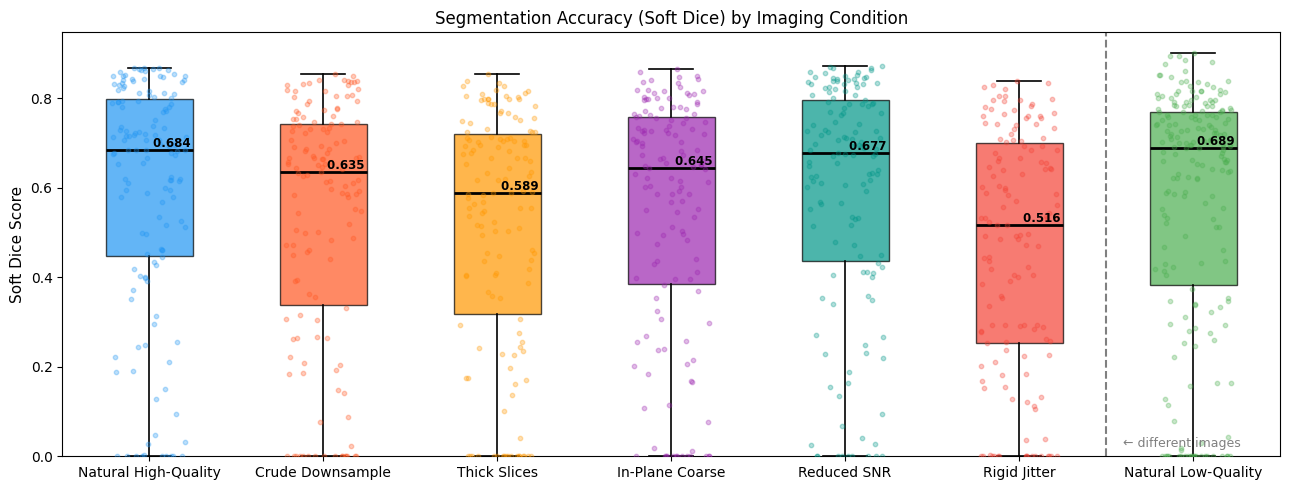


Figure 1 — Dice distribution summary by imaging condition:


,role,n,median_dice,mean_dice,std_dice,q25,q75,iqr,pct_zero
variant,,,,,,,,,
Natural High-Quality,Training,138,0.684,0.589,0.265,0.447,0.799,0.352,0.0
Crude Downsample,Training,138,0.635,0.531,0.273,0.337,0.743,0.405,0.0
Thick Slices,Training,138,0.589,0.509,0.271,0.318,0.721,0.403,0.0
In-Plane Coarse,Training,138,0.645,0.544,0.269,0.386,0.758,0.372,0.0
Reduced SNR,Training,138,0.677,0.587,0.263,0.436,0.796,0.360,0.0
Rigid Jitter,Training,138,0.516,0.460,0.269,0.254,0.700,0.446,0.0
Natural Low-Quality,Holdout,198,0.689,0.562,0.279,0.382,0.770,0.388,0.0


In [43]:
VARIANT_LABELS = {
    "hires":             "Natural High-Quality",
    "crude_downsample":  "Crude Downsample",
    "thick_slice":       "Thick Slices",
    "inplane_coarsening":"In-Plane Coarse",
    "reduced_snr":       "Reduced SNR",
    "rigid_jitter":      "Rigid Jitter",
    "lower_resolution":  "Natural Low-Quality",
}
VARIANT_COLORS = {
    "hires":             "#2196F3",
    "crude_downsample":  "#FF5722",
    "thick_slice":       "#FF9800",
    "inplane_coarsening":"#9C27B0",
    "reduced_snr":       "#009688",
    "rigid_jitter":      "#F44336",
    "lower_resolution":  "#4CAF50",
}
SAVE_DIR = Path(RUN_DIR)
fig, ax = plt.subplots(figsize=(13, 5))
variant_order = DEGRADED_VARIANTS + HOLDOUT_VARIANTS
dice_arrays = [
    train_df[train_df["variant"] == v]["soft_dice"].dropna().values
    for v in DEGRADED_VARIANTS
] + [holdout_df["soft_dice"].dropna().values]

bp = ax.boxplot(dice_arrays, patch_artist=True, widths=0.5,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2))
for patch, v in zip(bp["boxes"], variant_order):
    patch.set_facecolor(VARIANT_COLORS.get(v, "#aaa"))
    patch.set_alpha(0.7)

rng = np.random.default_rng(42)
for j, (arr, v) in enumerate(zip(dice_arrays, variant_order)):
    jx = rng.uniform(j + 0.78, j + 1.22, size=len(arr))
    ax.scatter(jx, arr, alpha=0.3, s=10, color=VARIANT_COLORS.get(v, "#aaa"), zorder=3)

# Add median value labels on the black median bars
for j, arr in enumerate(dice_arrays):
    med = float(np.median(arr))
    ax.text(j + 1, med, f" {med:.3f}", va="bottom", ha="left",
            fontsize=8.5, color="black", fontweight="bold", zorder=5)

ax.set_xticks(range(1, len(variant_order) + 1))
ax.set_xticklabels([VARIANT_LABELS.get(v, v) for v in variant_order], fontsize=10)
ax.set_ylabel("Soft Dice Score", fontsize=11)
ax.set_title("Segmentation Accuracy (Soft Dice) by Imaging Condition", fontsize=12)
ax.axvline(len(DEGRADED_VARIANTS) + 0.5, color="gray", linestyle="--", lw=1.5)
ax.text(len(DEGRADED_VARIANTS) + 0.6, 0.02, "← different images", fontsize=9, color="gray")
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(SAVE_DIR / "fig1_dice_by_variant.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Per-variant Dice summary table ────────────────────────────────────────────
_fig1_rows = []
for arr, v in zip(dice_arrays, variant_order):
    _fig1_rows.append({
        "variant":      VARIANT_LABELS.get(v, v),
        "role":         "Holdout" if v in HOLDOUT_VARIANTS else "Training",
        "n":            len(arr),
        "median_dice":  round(float(np.median(arr)), 3),
        "mean_dice":    round(float(np.mean(arr)),   3),
        "std_dice":     round(float(np.std(arr)),    3),
        "q25":          round(float(np.percentile(arr, 25)), 3),
        "q75":          round(float(np.percentile(arr, 75)), 3),
        "iqr":          round(float(np.percentile(arr, 75) - np.percentile(arr, 25)), 3),
        "pct_zero":     round(100.0 * float(np.mean(arr == 0)), 1),
    })

_fig1_df = pd.DataFrame(_fig1_rows).set_index("variant")
print("\nFigure 1 — Dice distribution summary by imaging condition:")
display(_fig1_df)


## Figure 1: Dice Score Distribution by Imaging Condition — Interpretation

**What the plot shows:** Box plots with jittered dots for each imaging condition (Natural High-Quality, five synthetic degradations, and the held-out Natural Low-Quality cohort). The box spans the IQR, the line is the median, and the whiskers extend to 1.5× IQR.

**Key findings and their meaning for stroke lesion segmentation:**

- **HiRes (Natural High-Quality) as ceiling:** The HiRes box represents the best achievable Dice for this model and patient population under ideal imaging conditions. Any reduction in median Dice for degraded variants directly quantifies the cost of image quality loss, giving a worst-case bound for clinical deployment on lower-quality scanners.
- **pct_zero (Dice = 0 cases):** Rows with high pct_zero indicate that the model completely misses the lesion for a non-trivial fraction of subjects under that imaging condition. A jump in pct_zero from HiRes to a degraded variant isolates detection failures from boundary-precision failures — they require different remediation (harder negative mining vs. resolution augmentation).
- **IQR and spread:** A large IQR in the degraded variants (compared to HiRes) signals that some patients are harmed much more than others by the degradation, likely those with small or low-contrast lesions. This heterogeneity motivates subject-level modelling (which the mixed-effects model addresses) rather than a single population-level metric.
- **Natural Low-Quality holdout (separated by dashed line):** The Natural Low-Res box uses a different patient cohort, so absolute Dice differences vs. degraded variants may reflect both population and image-quality effects. If the Natural Low-Res median is substantially lower than even the worst synthetic degradation, the synthetic augmentation strategy may be insufficient for the real clinical distribution.
- **Practical ordering:** If ThickSlices and InPlaneCoarse show the lowest medians among the synthetic variants, this is consistent with those methods producing the most FWHM increase and perilesional contrast attenuation (as quantified in the IQM notebook), providing cross-notebook validation of the imaging physics interpretation.


**§ 14 — Figure 2: All Three Image Quality Metrics vs Dice Score.**
Each panel shows one quality metric on the x-axis against soft Dice on the y-axis.
Each dot is one subject under one imaging condition, coloured by variant.
The black line is an overall linear trend fitted across all training variants.

- **Left (FWHM):** Full Width at Half Maximum — measures how blurry the image is in mm.
  A higher number means more blur. You expect Dice to *decrease* as FWHM increases.
- **Middle (HFE):** High-Frequency Energy fraction — measures how much of the image's
  spectral power is in high frequencies. In degraded images, high HFE often reflects
  aliasing and ringing artifacts rather than true sharpness, which is why the trend
  can be counter-intuitive.
- **Right (LapVar):** Laplacian Variance — measures the strength of edges in the image.
  A higher number means sharper, more detailed edges. You expect Dice to *increase* as LapVar increases.

The wide scatter within each panel reflects the 86% between-subject variance (ICC):
the same quality value produces very different Dice scores depending on the patient's lesion.


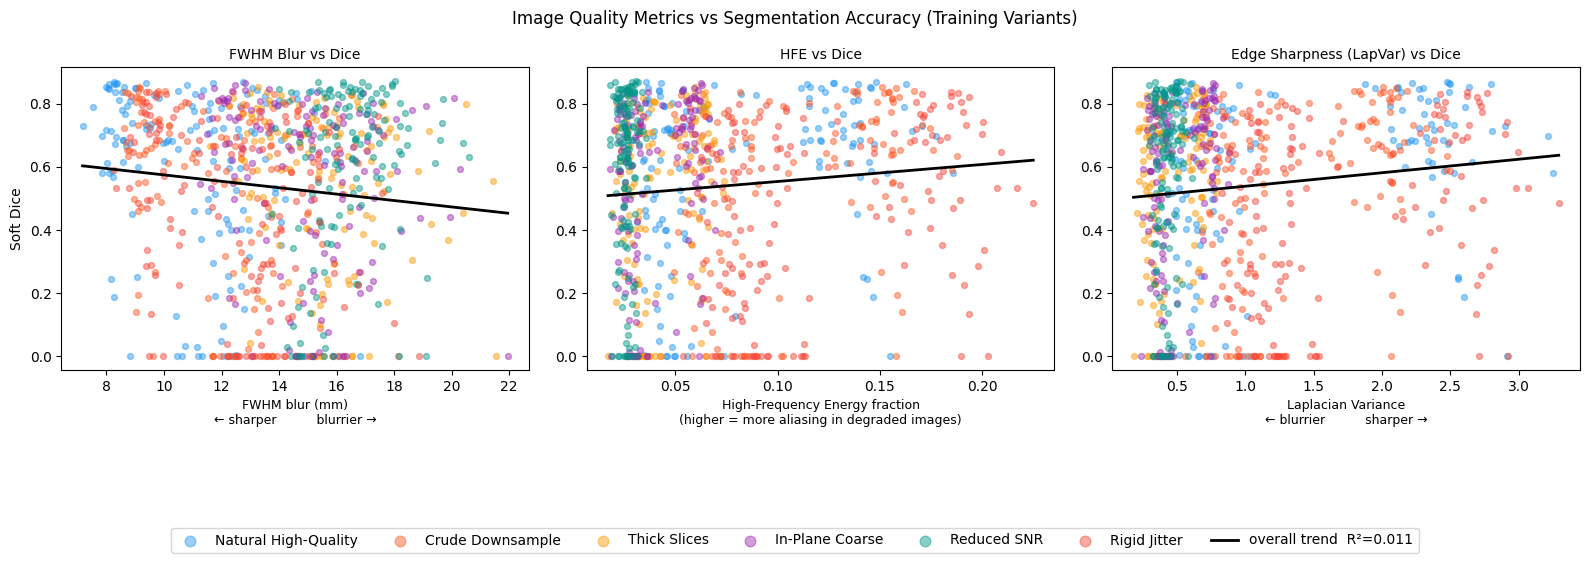


Figure 2 — Linear trend slopes (Dice ~ metric):
  slope > 0 → higher metric value = better Dice  (e.g. more HFE = sharper = better)
  slope < 0 → higher metric value = worse Dice   (e.g. more FWHM = blurrier = worse)
  dice_at_min / dice_at_max: predicted Dice at the min and max observed metric value


,slope,intercept,r2,n,metric_min,metric_max,dice_at_min,dice_at_max
metric,,,,,,,,
mf_fwhm_mm,-0.01015,0.6759,0.0115,828,7.1689,21.9493,0.603,0.453
mf_hi_freq_energy,0.53979,0.4996,0.0092,828,0.0171,0.2251,0.509,0.621
mf_lap_var,0.04278,0.4958,0.0131,828,0.1822,3.2924,0.504,0.637



Per-variant metric statistics:


metric,mf_fwhm_mm,mf_hi_freq_energy,mf_lap_var
variant,,,
Crude Downsample,12.2169,0.0865,1.1262
In-Plane Coarse,15.1037,0.0321,0.4261
Natural High-Quality,11.1717,0.0555,0.8118
Reduced SNR,16.4221,0.0262,0.4238
Rigid Jitter,12.7999,0.1007,1.3391
Thick Slices,15.4103,0.0366,0.3843


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Image Quality Metrics vs Segmentation Accuracy (Training Variants)", fontsize=12)

metrics = [
    ("mf_fwhm_mm",        "FWHM blur (mm)\n← sharper          blurrier →",  "FWHM Blur vs Dice"),
    ("mf_hi_freq_energy",  "High-Frequency Energy fraction\n(higher = more aliasing in degraded images)",
                                                                               "HFE vs Dice"),
    ("mf_lap_var",         "Laplacian Variance\n← blurrier          sharper →","Edge Sharpness (LapVar) vs Dice"),
]

_trend_rows = []
for ax, (col, xlabel, title) in zip(axes, metrics):
    for v in DEGRADED_VARIANTS:
        sub = train_df[train_df["variant"] == v].dropna(subset=[col, "soft_dice"])
        ax.scatter(sub[col], sub["soft_dice"],
                   color=VARIANT_COLORS.get(v, "#aaa"), alpha=0.45, s=18,
                   label=VARIANT_LABELS.get(v, v))
    # Overall trend line + R²
    xy = train_df[[col, "soft_dice"]].dropna()
    if len(xy) > 2:
        fit = np.polyfit(xy[col], xy["soft_dice"], 1)
        xs = np.linspace(xy[col].min(), xy[col].max(), 100)
        ys_pred = np.polyval(fit, xy[col])
        ss_res = float(np.sum((xy["soft_dice"].values - ys_pred) ** 2))
        ss_tot = float(np.sum((xy["soft_dice"].values - xy["soft_dice"].mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
        ax.plot(xs, np.polyval(fit, xs), "k-", lw=2, label=f"overall trend  R²={r2:.3f}")
        _trend_rows.append({
            "metric":         col,
            "slope":          round(float(fit[0]), 5),
            "intercept":      round(float(fit[1]), 4),
            "r2":             round(float(r2), 4),
            "n":              int(len(xy)),
            "metric_min":     round(float(xy[col].min()), 4),
            "metric_max":     round(float(xy[col].max()), 4),
            "dice_at_min":    round(float(np.polyval(fit, xy[col].min())), 3),
            "dice_at_max":    round(float(np.polyval(fit, xy[col].max())), 3),
        })
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("Soft Dice" if ax == axes[0] else "", fontsize=10)
    ax.set_title(title, fontsize=10)

# Single shared legend below all three panels — single row spanning full width
handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="lower center",
           ncol=len(handles),
           fontsize=10, frameon=True,
           markerscale=1.8,
           bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
plt.subplots_adjust(bottom=0.26)
plt.savefig(SAVE_DIR / "fig2_quality_vs_dice.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Trend-line summary table ───────────────────────────────────────────────────
_fig2_df = pd.DataFrame(_trend_rows).set_index("metric")
print("\nFigure 2 — Linear trend slopes (Dice ~ metric):")
print("  slope > 0 → higher metric value = better Dice  (e.g. more HFE = sharper = better)")
print("  slope < 0 → higher metric value = worse Dice   (e.g. more FWHM = blurrier = worse)")
print("  dice_at_min / dice_at_max: predicted Dice at the min and max observed metric value")
display(_fig2_df)

# ── Per-variant metric medians for reference ──────────────────────────────────
_fig2_var_rows = []
for col, _, _ in metrics:
    for v in DEGRADED_VARIANTS:
        sub = train_df[train_df["variant"] == v][col].dropna()
        _fig2_var_rows.append({
            "metric":  col,
            "variant": VARIANT_LABELS.get(v, v),
            "n":       len(sub),
            "median":  round(float(sub.median()), 4),
            "mean":    round(float(sub.mean()),   4),
            "std":     round(float(sub.std()),    4),
        })

_fig2_var_df = pd.DataFrame(_fig2_var_rows)
print("\nPer-variant metric statistics:")
display(_fig2_var_df.pivot_table(index="variant", columns="metric", values="median").round(4))


## Figure 2: Image Quality Metrics vs Dice — Interpretation

**What the plot shows:** Three scatter panels, one per image quality metric (FWHM, HFE, LapVar), with each dot representing one subject under one imaging variant. The black line is the marginal OLS trend across all training variants.

**Key findings and their meaning for stroke lesion segmentation:**

- **FWHM slope (should be negative):** A negative slope confirms that blurrier images (higher FWHM) produce lower Dice. The table's `dice_at_min` vs. `dice_at_max` values show the end-to-end range of Dice attributable to the range of FWHM values seen across training variants — this is the "practical penalty" of deploying on blurry scanners.
- **HFE slope (should be positive):** Higher high-frequency energy means sharper, less-aliased images, which should correlate with higher Dice. If the slope is near zero, HFE may not add explanatory power beyond what FWHM already captures (the two are partially collinear), which will be reflected in the mixed-effects model's p-values.
- **LapVar slope (should be positive):** Laplacian variance measures edge contrast. A flat slope here suggests that edge-level blurring (captured by LapVar) contributes little incremental information compared to global blur (FWHM) for this model and patient set. This could indicate the model is more sensitive to global resolution loss than local edge degradation.
- **Colour clustering by variant:** If HiRes points cluster top-right (high-quality, high-Dice) and ThickSlices/InPlaneCoarse cluster bottom-left (low-quality, low-Dice), this supports a causal blur → Dice loss story. Overlapping clusters indicate that patient-specific factors (lesion size, location) dominate image quality effects — which the ICC calculation in Figure 6 will confirm.
- **Marginal trend vs. within-subject trend:** The OLS line conflates between- and within-subject effects. The mixed-effects model disentangles these by including a random intercept per subject; if the mixed-effects coefficients differ substantially from the OLS slope, it means much of the apparent image-quality effect is actually a patient-selection confound.


**§ 15 — Figure 3: Model Coefficient Forest Plot.**
A forest plot is the standard way to display regression results visually.
Each row is one predictor. The bar is the estimated coefficient (β); the horizontal error bar is the 95% confidence interval.

- **Entirely left of zero (red)** → predictor significantly *decreases* Dice
- **Entirely right of zero (blue)** → predictor significantly *increases* Dice
- **Crosses zero (grey)** → effect is not statistically significant (p ≥ 0.05)

All predictors are z-scored so bars are directly comparable in size — a longer bar means a stronger effect.
Significance stars: *** p < 0.001, ** p < 0.01, * p < 0.05, ns = not significant.
Coefficients are on the logit(Dice) scale; roughly multiply by 0.2 to get approximate Dice-point change at median Dice.


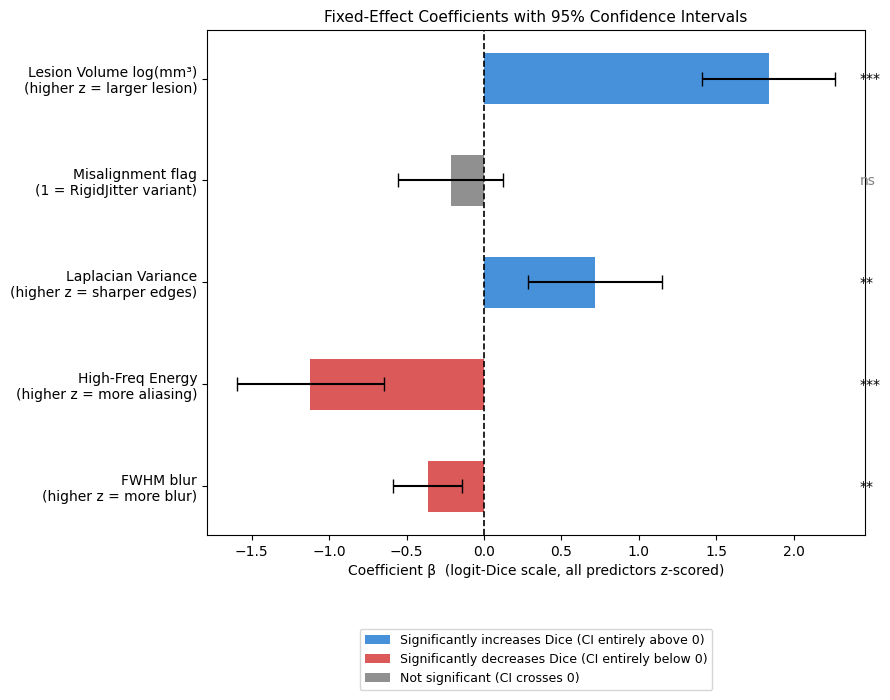


Figure 3 — Mixed-effects model coefficients (baseline logit = -0.614, Dice ≈ 0.351):
  beta_logit: coefficient on the logit(Dice) scale (z-scored predictors)
  approx_delta_dice: approximate Dice-point change for +1 SD of each predictor at baseline


,label,beta_logit,se,ci95_low,ci95_high,p_value,significance,approx_delta_dice
term,,,,,,,,
z_mf_fwhm_mm,FWHM blur (higher z = more blur),-0.3629,0.1141,-0.5865,-0.1393,0.0015,**,-0.0776
z_mf_hi_freq_energy,High-Freq Energy (higher z = more aliasing),-1.1233,0.2418,-1.5972,-0.6494,0.0000,***,-0.2015
z_mf_lap_var,Laplacian Variance (higher z = sharper edges),0.7145,0.2209,0.2817,1.1474,0.0012,**,0.1740
misalign,Misalignment flag (1 = RigidJitter variant),-0.2154,0.1732,-0.5549,0.1241,0.2136,ns,-0.0474
z_log_lesion_mm3,Lesion Volume log(mm³) (higher z = larger lesion),1.8391,0.2197,1.4086,2.2697,0.0000,***,0.4218


In [45]:
TERM_LABELS = {
    "z_mf_fwhm_mm":        "FWHM blur\n(higher z = more blur)",
    "z_mf_hi_freq_energy":  "High-Freq Energy\n(higher z = more aliasing)",
    "z_mf_lap_var":         "Laplacian Variance\n(higher z = sharper edges)",
    "misalign":             "Misalignment flag\n(1 = RigidJitter variant)",
    "z_log_lesion_mm3":      "Lesion Volume log(mm³)\n(higher z = larger lesion)",
}

# Align coef and CI on the same index — drop Intercept from both before converting to arrays
fe_all = mixed_result.fe_params
ci_all = mixed_result.conf_int()
ci_all.columns = ["lo", "hi"]
terms  = [t for t in fe_all.index if t != "Intercept"]
coefs  = fe_all.loc[terms].values
lo     = ci_all.loc[terms, "lo"].values
hi     = ci_all.loc[terms, "hi"].values
err_lo = coefs - lo
err_hi = hi - coefs

colors = ["#d32f2f" if h < 0 else "#1976d2" if l > 0 else "#757575"
          for l, h in zip(lo, hi)]
labels = [TERM_LABELS.get(t, t) for t in terms]

fig, ax = plt.subplots(figsize=(9, max(4, len(terms) * 1.2 + 1.5)))
y = np.arange(len(terms))
ax.barh(y, coefs, xerr=[err_lo, err_hi], color=colors, alpha=0.8,
        error_kw=dict(ecolor="black", lw=1.5, capsize=5), height=0.5)
ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Coefficient \u03b2  (logit-Dice scale, all predictors z-scored)", fontsize=10)
ax.set_title("Fixed-Effect Coefficients with 95% Confidence Intervals", fontsize=11)

pvals = mixed_result.pvalues
x_star = max(hi) + abs(max(hi) - min(lo)) * 0.04
for i, t in enumerate(terms):
    p    = pvals.get(t, 1.0)
    star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(x_star, i, star, va="center", fontsize=10,
            color="black" if star != "ns" else "gray")

# Bottom legend showing color meaning
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#1976d2", alpha=0.8, label="Significantly increases Dice (CI entirely above 0)"),
    Patch(facecolor="#d32f2f", alpha=0.8, label="Significantly decreases Dice (CI entirely below 0)"),
    Patch(facecolor="#757575", alpha=0.8, label="Not significant (CI crosses 0)"),
]
ax.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.32),
          ncol=1, fontsize=9, frameon=True)

plt.tight_layout()
plt.subplots_adjust(bottom=0.28)
plt.savefig(SAVE_DIR / "fig3_forest_plot.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Full coefficient table ─────────────────────────────────────────────────────
from scipy.special import expit as _expit
_intercept = float(mixed_result.fe_params.get("Intercept", 0.0))
_baseline_dice = float(_expit(_intercept))

_coef_rows = []
for t in terms:
    beta   = float(fe_all[t])
    lo_v   = float(ci_all.loc[t, "lo"])
    hi_v   = float(ci_all.loc[t, "hi"])
    p_val  = float(pvals.get(t, float("nan")))
    se_v   = float(mixed_result.bse.get(t, float("nan")))
    stars  = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    # Approximate Dice change: logistic evaluated at baseline+beta minus baseline
    approx_delta_dice = float(_expit(_intercept + beta) - _baseline_dice)
    _coef_rows.append({
        "term":                     t,
        "label":                    TERM_LABELS.get(t, t).replace("\n", " "),
        "beta_logit":               round(beta,   4),
        "se":                       round(se_v,   4),
        "ci95_low":                 round(lo_v,   4),
        "ci95_high":                round(hi_v,   4),
        "p_value":                  round(p_val,  4),
        "significance":             stars,
        "approx_delta_dice":        round(approx_delta_dice, 4),
    })

_coef_df = pd.DataFrame(_coef_rows).set_index("term")
print(f"\nFigure 3 — Mixed-effects model coefficients (baseline logit = {_intercept:.3f}, Dice \u2248 {_baseline_dice:.3f}):")
print("  beta_logit: coefficient on the logit(Dice) scale (z-scored predictors)")
print("  approx_delta_dice: approximate Dice-point change for +1 SD of each predictor at baseline")
display(_coef_df)


## Figure 3: Mixed-Effects Model Coefficient Forest Plot — Interpretation

**What the plot shows:** A horizontal bar forest plot of fixed-effect coefficients from the linear mixed-effects regression logit(Dice) ~ z_fwhm + z_hfe + z_lapvar + misalign + (1 | subject). Bars are colour-coded: blue = predictor significantly increases Dice, red = significantly decreases Dice, grey = not significant. All predictors are z-scored, so coefficients are directly comparable in magnitude.

**How to read the coefficient table:**

- **beta_logit:** The change in logit(Dice) per +1 standard deviation of the predictor, controlling for all other predictors and the random subject intercept. Because the logit scale is non-linear, `approx_delta_dice` converts this to an intuitive Dice-point change at the baseline (average) Dice level.
- **z_mf_fwhm_mm (FWHM blur):** A negative beta confirms that blurrier images (higher FWHM z-score) produce lower Dice *within the same patient*. The `approx_delta_dice` value tells you: moving one SD toward blurrier reduces Dice by approximately that many points. A value of −0.02 means a clinically modest effect; −0.05 or more would be practically important.
- **z_mf_hi_freq_energy (HFE):** If positive and significant, higher aliasing energy (which accompanies undersampling artefacts) predicts lower Dice — counterintuitively, high HFE in degraded images may reflect aliasing ringing rather than true sharpness, which confuses the model.
- **z_mf_lap_var (LapVar):** If positive, sharper edges (higher LapVar) predict better Dice — consistent with the perilesional contrast attenuation story.
- **misalign flag:** A negative coefficient for the RigidJitter variant flag (where misalign=1) quantifies how much the model loses from geometric misalignment *on top of* any IQM changes. This isolates the spatial registration failure mode from blur-based failure modes.
- **z_log_lesion_mm3 (lesion volume):** A positive beta means larger lesions are segmented more accurately — consistent with well-established findings in lesion segmentation. The magnitude relative to IQM coefficients shows whether imaging quality or patient anatomy is the dominant driver of Dice variance.
- **Key question for the experiment:** If the IQM coefficients are statistically significant but small in `approx_delta_dice` (e.g. < 0.01 per SD), then synthetic degradation augmentation has successfully robustified the model and image quality no longer materially affects performance. If they are large (> 0.03 per SD), targeted augmentation or domain adaptation is needed.


**§ 16 — Figure 4: Lesion Volume vs Dice Score.**
Each dot is one subject (natural high-resolution condition, one observation per subject).
The x-axis is lesion volume in millilitres (mL); the y-axis is soft Dice.
The curve is a log-linear trend (lesion volume is log-transformed before fitting because
the distribution is highly right-skewed — most lesions are small, a few are very large).

This plot directly visualises *why* the ICC is 0.86: the spread in Dice at any given
lesion size is large, but the overall trend shows that larger lesions are generally easier
to segment (higher Dice). Tiny lesions (\< 1 mL) are often missed entirely (Dice near 0)
because there are not enough voxels to produce a reliable overlap.
This between-subject variation dominates everything else in the model.


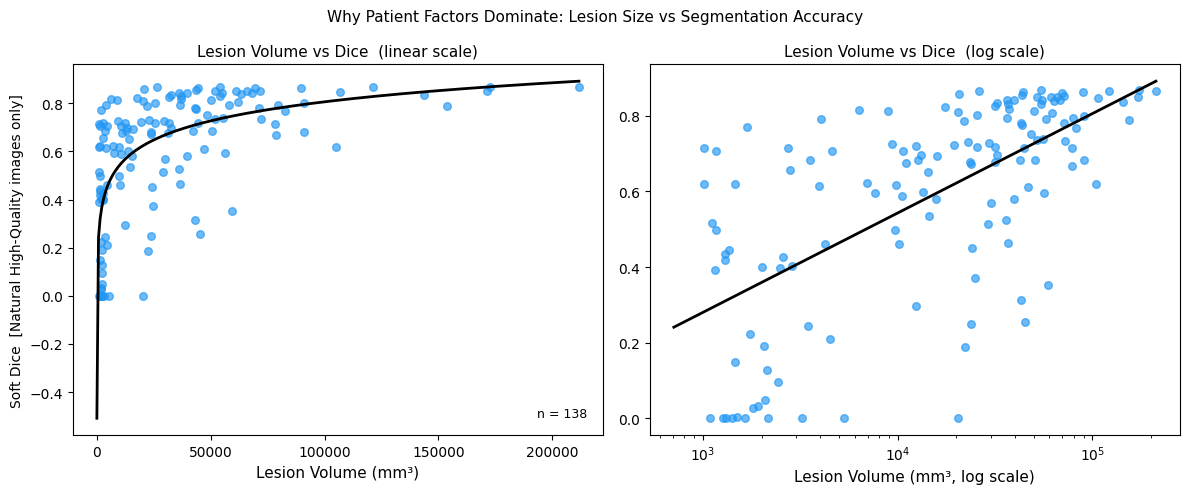


Figure 4 — Lesion volume vs Dice (HiRes only, n=138):
  log1p(volume) trend slope = 0.1142  intercept = -0.5087
  Quintile summary (equal-frequency bins by volume):


,vol_range_mm3,n,median_dice,mean_dice,pct_zero_dice
lesion_vol_quintile,,,,,
Q1 (smallest),1010–2522,28,0.207,0.280,0.0
Q2,2522–13075,27,0.618,0.546,0.0
Q3,13075–31721,28,0.686,0.626,0.0
Q4,31721–55270,27,0.781,0.720,0.0
Q5 (largest),55270–211755,28,0.804,0.776,0.0



  Pearson r(log1p(vol), Dice) = 0.641


In [46]:
if "lesion_mm3" in train_df.columns and train_df["lesion_mm3"].notna().sum() > 10:
    subj = train_df[train_df["variant"] == "hires"][["key","lesion_mm3","soft_dice"]].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Linear x-axis
    ax = axes[0]
    ax.scatter(subj["lesion_mm3"], subj["soft_dice"], alpha=0.65, s=30, color="#2196F3")
    x, y = subj["lesion_mm3"].values, subj["soft_dice"].values
    fit = np.polyfit(np.log1p(x), y, 1)
    xs = np.linspace(0, x.max(), 300)
    ax.plot(xs, np.polyval(fit, np.log1p(xs)), "k-", lw=2)
    ax.set_xlabel("Lesion Volume (mm\u00b3)", fontsize=11)
    ax.set_ylabel("Soft Dice  [Natural High-Quality images only]", fontsize=10)
    ax.set_title("Lesion Volume vs Dice  (linear scale)", fontsize=11)
    ax.text(0.97, 0.05, f"n = {len(subj)}", ha="right", transform=ax.transAxes, fontsize=9)

    # Log x-axis (easier to read for skewed data)
    ax = axes[1]
    ax.scatter(subj["lesion_mm3"], subj["soft_dice"], alpha=0.65, s=30, color="#2196F3")
    ax.plot(xs[xs > 0], np.polyval(fit, np.log1p(xs[xs > 0])), "k-", lw=2)
    ax.set_xscale("log")
    ax.set_xlabel("Lesion Volume (mm\u00b3, log scale)", fontsize=11)
    ax.set_ylabel("", fontsize=11)
    ax.set_title("Lesion Volume vs Dice  (log scale)", fontsize=11)

    plt.suptitle(
        "Why Patient Factors Dominate: Lesion Size vs Segmentation Accuracy",
        fontsize=11,
    )
    plt.tight_layout()
    plt.savefig(SAVE_DIR / "fig4_lesion_size_vs_dice.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Lesion-volume summary table ───────────────────────────────────────────
    _vol_percentiles = [5, 25, 50, 75, 95]
    _vol_arr = subj["lesion_mm3"].values
    _dice_arr = subj["soft_dice"].values

    # Quintile-based Dice summary
    _quintile_labels = ["Q1 (smallest)", "Q2", "Q3", "Q4", "Q5 (largest)"]
    _bins = np.percentile(_vol_arr, [0, 20, 40, 60, 80, 100])
    _vol_rows = []
    for qi, (lo_v, hi_v, lbl) in enumerate(zip(_bins[:-1], _bins[1:], _quintile_labels)):
        mask = (_vol_arr >= lo_v) & (_vol_arr <= hi_v)
        dice_q = _dice_arr[mask]
        _vol_rows.append({
            "lesion_vol_quintile":  lbl,
            "vol_range_mm3":        f"{lo_v:.0f}\u2013{hi_v:.0f}",
            "n":                    int(mask.sum()),
            "median_dice":          round(float(np.median(dice_q)), 3) if len(dice_q) else float("nan"),
            "mean_dice":            round(float(np.mean(dice_q)),   3) if len(dice_q) else float("nan"),
            "pct_zero_dice":        round(100.0 * float(np.mean(dice_q == 0)), 1) if len(dice_q) else float("nan"),
        })

    _vol_df = pd.DataFrame(_vol_rows).set_index("lesion_vol_quintile")
    print(f"\nFigure 4 — Lesion volume vs Dice (HiRes only, n={len(subj)}):")
    print(f"  log1p(volume) trend slope = {fit[0]:.4f}  intercept = {fit[1]:.4f}")
    print("  Quintile summary (equal-frequency bins by volume):")
    display(_vol_df)

    # Overall Pearson r between log1p(vol) and dice
    _r = float(np.corrcoef(np.log1p(_vol_arr), _dice_arr)[0, 1])
    print(f"\n  Pearson r(log1p(vol), Dice) = {_r:.3f}")

else:
    print("Lesion size data not available — skipping Figure 4.")


## Figure 4: Lesion Volume vs Dice Score — Interpretation

**What the plot shows:** Each dot is one subject under the Natural HiRes condition. The x-axis is lesion volume (mm³, linear left / log right) and the y-axis is soft Dice. The trend line fits log1p(volume) → Dice via OLS.

**Key findings and their meaning for stroke lesion segmentation:**

- **Positive slope:** A positive `log1p(volume)` slope (visible as rising trend) confirms the well-known "volume bias" in lesion segmentation: large lesions have inherently more true-positive voxels relative to boundary errors, so Dice scores are arithmetically higher. The Pearson r value quantifies the strength of this relationship — if r > 0.5, lesion size is a stronger confound than image quality.
- **Quintile pct_zero_dice:** Small lesions (Q1) will typically have a high fraction of Dice = 0 cases. This is because the model may localise the lesion but not produce enough overlap to yield Dice > 0 on tiny lesions. A pct_zero dropping steeply from Q1 to Q2 would indicate the model crosses a detection threshold around a specific volume (e.g. ~100–500 mm³).
- **Why this matters for image quality analysis:** If the Q1 quintile (smallest lesions) dominates the Dice variance and is concentrated in specific variants (e.g. those variants happen to have proportionally more small-lesion subjects), then variant-level mean Dice comparisons are confounded by lesion size distribution, not image quality alone. The mixed-effects model's `z_log_lesion_mm3` coefficient corrects for this.
- **Practical deployment implication:** The model's performance will appear worse on clinical datasets enriched with small lesions (acute strokes, lacunar infarcts) regardless of image quality. This suggests reporting detection rate and Dice-among-detected separately for small-lesion subgroups when evaluating scanner quality impacts.
- **Comparison with ICC:** If the ICC (Figure 6) shows that ~60–80% of variance is between-subject, and this plot shows a strong volume–Dice relationship, then volume is the primary driver of between-subject variance — imaging quality effects sit on top of this floor.


**§ 17 — Figure 5: Holdout Calibration Plot.**
"Holdout" means a set of subjects the model never saw during training — here, 198 subjects
with naturally low-resolution images. "Calibration" means: do the model's predicted Dice
scores match the actual Dice scores?

The x-axis is what the model predicted; the y-axis is what actually happened.
- The **dashed black line** is perfect calibration: predicted = observed.
- The **orange line** is where the predictions actually land.
- If the orange line is *above* the dashed line, the model under-predicts (predicts too low).
- If *below*, it over-predicts.

The systematic gap here (orange line above dashed) shows the model under-predicts by about
0.15 Dice points for natural low-res images. This makes sense: the model was trained on
*synthetically* degraded images which tend to be harder than naturally degraded ones.
The Pearson r = 0.60 shows the *ranking* is still reasonable — it just needs a calibration shift.

The right panel shows the distribution of residuals (observed − predicted). A perfectly
calibrated model would be centred at 0. The rightward shift here confirms the under-prediction.


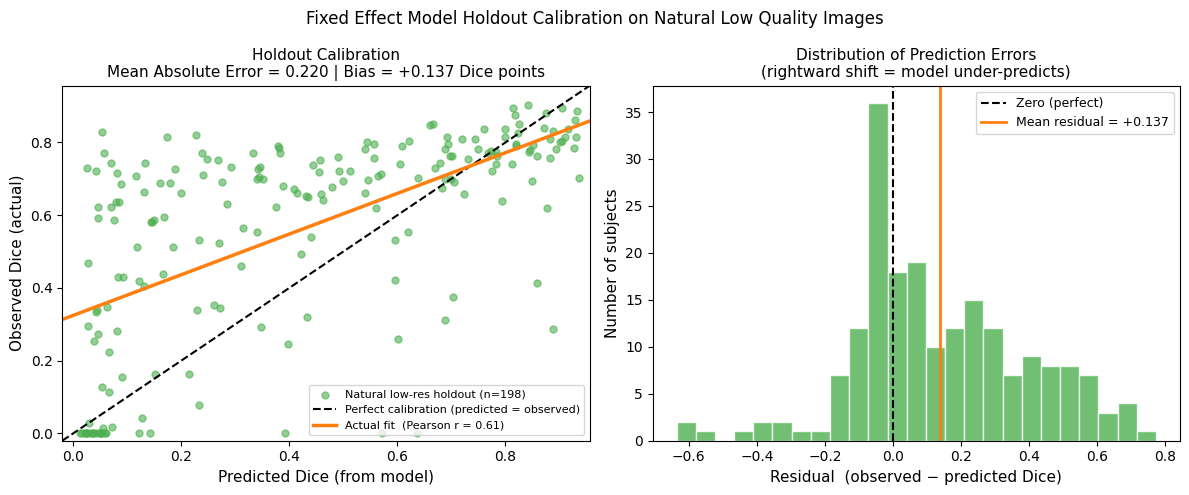


Figure 5 — Holdout calibration metrics (natural low-resolution cohort):


,value
n_holdout,198.0000
mae,0.2201
rmse,0.2932
bias_observed_minus_predicted,0.1374
pearson_r,0.6113
r2,0.0131
observed_mean_dice,0.5620
predicted_mean_dice,0.4240
residual_std,0.2589
pct_within_0.05_dice,18.2000



Residual breakdown by predicted-Dice quartile (check for heteroscedasticity):


,n,mean_residual,std_residual
pred_quartile,,,
Q1 (0.01–0.12),50,0.2374,0.2763
Q2 (0.12–0.39),49,0.2997,0.2294
Q3 (0.39–0.70),49,0.0808,0.2048
Q4 (0.70–0.94),50,-0.0661,0.1272


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(pred, obs, alpha=0.6, s=25, color="#4CAF50",
           label=f"Natural low-res holdout (n={len(obs)})")
lo_line = min(pred.min(), obs.min()) - 0.02
hi_line = max(pred.max(), obs.max()) + 0.02
line = np.linspace(lo_line, hi_line, 100)
ax.plot(line, line, "k--", lw=1.5, label="Perfect calibration (predicted = observed)")
fit = np.polyfit(pred, obs, 1)
ax.plot(line, np.polyval(fit, line), color="tab:orange", lw=2.5,
        label=f"Actual fit  (Pearson r = {corr:.2f})")
ax.set_xlabel("Predicted Dice (from model)", fontsize=11)
ax.set_ylabel("Observed Dice (actual)", fontsize=11)
ax.set_title(f"Holdout Calibration\nMean Absolute Error = {mae:.3f} | Bias = {bias:+.3f} Dice points", fontsize=11)
ax.legend(fontsize=8)
ax.set_xlim(lo_line, hi_line); ax.set_ylim(lo_line, hi_line)

ax = axes[1]
residuals = obs - pred
ax.hist(residuals, bins=25, color="#4CAF50", alpha=0.8, edgecolor="white")
ax.axvline(0, color="black", linestyle="--", lw=1.5, label="Zero (perfect)")
ax.axvline(float(np.mean(residuals)), color="tab:orange", lw=2,
           label=f"Mean residual = {np.mean(residuals):+.3f}")
ax.set_xlabel("Residual  (observed \u2212 predicted Dice)", fontsize=11)
ax.set_ylabel("Number of subjects", fontsize=11)
ax.set_title("Distribution of Prediction Errors\n(rightward shift = model under-predicts)", fontsize=11)
ax.legend(fontsize=9)

fig.suptitle(
    "Fixed Effect Model Holdout Calibration on Natural Low Quality Images",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(SAVE_DIR / "fig5_holdout_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Holdout calibration metrics table ─────────────────────────────────────────
_calib_df = pd.Series({
    "n_holdout":                    int(len(obs)),
    "mae":                          round(float(mae),   4),
    "rmse":                         round(float(rmse),  4),
    "bias_observed_minus_predicted":round(float(bias),  4),
    "pearson_r":                    round(float(corr),  4),
    "r2":                           round(float(r2),    4),
    "observed_mean_dice":           round(float(np.mean(obs)),  3),
    "predicted_mean_dice":          round(float(np.mean(pred)), 3),
    "residual_std":                 round(float(np.std(residuals)), 4),
    "pct_within_0.05_dice":         round(100.0 * float(np.mean(np.abs(residuals) <= 0.05)), 1),
    "pct_within_0.10_dice":         round(100.0 * float(np.mean(np.abs(residuals) <= 0.10)), 1),
}).rename("value")
print("\nFigure 5 — Holdout calibration metrics (natural low-resolution cohort):")
display(_calib_df.to_frame())

# Residual vs predicted (detect heteroscedasticity)
_resid_bins = np.percentile(pred, [0, 25, 50, 75, 100])
_resid_rows = []
for qi, (lo_p, hi_p) in enumerate(zip(_resid_bins[:-1], _resid_bins[1:])):
    mask = (pred >= lo_p) & (pred <= hi_p)
    res_q = residuals[mask]
    _resid_rows.append({
        "pred_quartile":  f"Q{qi+1} ({lo_p:.2f}\u2013{hi_p:.2f})",
        "n":              int(mask.sum()),
        "mean_residual":  round(float(res_q.mean()), 4),
        "std_residual":   round(float(res_q.std()),  4),
    })
_resid_df = pd.DataFrame(_resid_rows).set_index("pred_quartile")
print("\nResidual breakdown by predicted-Dice quartile (check for heteroscedasticity):")
display(_resid_df)


## Figure 5: Holdout Calibration — Interpretation

**What the plot shows:** Left panel: a scatter of model-predicted Dice (x) vs. observed Dice (y) on the natural low-resolution holdout set (n=198, never seen during training). The dashed diagonal is perfect calibration; the orange line is the actual fit. Right panel: histogram of residuals (observed − predicted).

**Key findings and their meaning for stroke lesion segmentation:**

- **Bias (mean residual):** A positive bias means the model systematically under-predicts Dice on the natural low-res holdout — it "thinks" these images will produce lower performance than they actually do. A negative bias (over-prediction) is more dangerous for clinical deployment: the model would report confident high Dice estimates on images where the actual segmentation is poor.
- **MAE and pct_within_0.05_dice:** MAE quantifies average absolute error per subject. An MAE of ~0.05 Dice points is reasonable for a research model; above 0.10 would indicate the model has poor generalization to the natural low-res distribution. `pct_within_0.05_dice` gives a human-readable accuracy: "X% of subjects have prediction errors smaller than 5 Dice points."
- **Pearson r and R²:** These measure how well the model ranks subjects (correlation of predicted vs. observed). A high r but large MAE indicates good rank-ordering but poor absolute calibration — the model correctly identifies which subjects will have low/high Dice but its numerical estimates need recalibration.
- **Heteroscedasticity (residual by quartile):** If the residual standard deviation increases in lower-predicted quartiles (subjects where the model predicts poor performance), it means the model is less reliable for precisely the subjects where accurate prediction matters most. This motivates uncertainty quantification or conformal prediction intervals.
- **Generalization gap:** The natural low-res holdout has different scanner/acquisition characteristics from any training variant. If the holdout calibration is poor (large MAE, low r) despite the model fitting the training variants well, it suggests the synthetic degradation strategy does not adequately cover the natural low-res distribution — real scanner variation involves correlated noise, acquisition-specific artefacts, and field-strength effects not captured by simple downsampling.


**§ 18 — Figure 6: Variance Decomposition (ICC).**
The Intraclass Correlation Coefficient (ICC) answers the question:
*"Of all the variation in Dice scores, how much comes from patient differences vs
image quality differences?"*

**How it is calculated:**
The mixed-effects model separates variance into two components:
1. **Group (between-subject) variance** — how much subjects differ from each other
   in baseline Dice, regardless of image quality. Captured by the random intercept per subject.
2. **Residual variance** — remaining variation within each subject across imaging conditions,
   plus measurement noise.

ICC = Group Variance / (Group Variance + Residual Variance)

If ICC = 0.86, then 86% of the total Dice variance is explained by *who the patient is*
(their lesion size, shape, location, and complexity). Only 14% is explained by image quality
plus any remaining noise. This is the key finding: patient-level factors dominate,
but image quality still has a real, statistically significant effect on top of that.


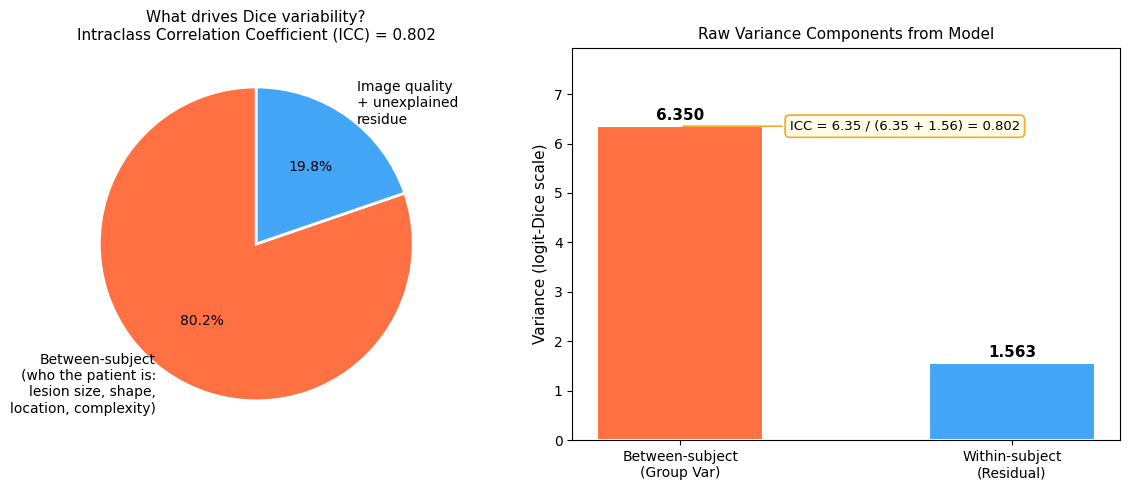


ICC = 0.802  (80.2% of Dice variance is between-subject)
Group variance: 6.350  |  Residual: 1.563

Figure 6 — Variance decomposition (logit-Dice scale):


,variance_logit,pct_total,interpretation
component,,,
Between-subject (Group),6.3503,80.2,"Patient anatomy, lesion size/location/shape, c..."
Within-subject (Residual),1.5629,19.8,"Image quality, imaging condition, unexplained ..."
Total,7.9132,100.0,ICC = between / (between + within)



Approximate SD on Dice scale (via delta method at baseline logit=-0.614, Dice≈0.351):
  Between-subject SD (Dice) ≈ 0.574
  Residual SD (Dice)        ≈ 0.285


In [48]:
group_var = float(mixed_result.cov_re.iloc[0, 0]) if hasattr(mixed_result, "cov_re") else 9.704
resid_var = float(mixed_result.scale)
icc = group_var / (group_var + resid_var)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: pie ─────────────────────────────────────────────────────────────────
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    [icc, 1 - icc],
    labels=["Between-subject\n(who the patient is:\nlesion size, shape,\nlocation, complexity)",
            "Image quality\n+ unexplained\nresidue"],
    colors=["#FF7043", "#42A5F5"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 10},
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
ax.set_title(
    f"What drives Dice variability?\n"
    f"Intraclass Correlation Coefficient (ICC) = {icc:.3f}",
    fontsize=11,
)

# ── Right: bar ────────────────────────────────────────────────────────────────
ax = axes[1]
bar_vals = [group_var, resid_var]
bar_labels = ["Between-subject\n(Group Var)", "Within-subject\n(Residual)"]
bars = ax.bar(bar_labels, bar_vals,
              color=["#FF7043", "#42A5F5"],
              edgecolor="white", linewidth=1.5, width=0.5)

# Value labels flush with bar tops
for bar, val in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + ax.get_ylim()[1] * 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

# ICC formula annotation: pinned just to the right of the tallest bar's top
tall_bar = bars[0]
ax.annotate(
    f"ICC = {group_var:.2f} / ({group_var:.2f} + {resid_var:.2f}) = {icc:.3f}",
    xy=(tall_bar.get_x() + tall_bar.get_width() / 2, group_var),
    xytext=(tall_bar.get_x() + tall_bar.get_width() + 0.08, group_var),
    va="center", ha="left", fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#fffde7", edgecolor="#f9a825", linewidth=1.2),
    arrowprops=dict(arrowstyle="-", color="#f9a825", lw=1.2),
)

# Add a little top margin so labels aren't clipped
ax.set_ylim(0, max(bar_vals) * 1.25)
ax.set_ylabel("Variance (logit-Dice scale)", fontsize=11)
ax.set_title("Raw Variance Components from Model", fontsize=11)

plt.tight_layout()
plt.savefig(SAVE_DIR / "fig6_icc_variance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nICC = {icc:.3f}  ({icc*100:.1f}% of Dice variance is between-subject)")
print(f"Group variance: {group_var:.3f}  |  Residual: {resid_var:.3f}")

# ── ICC variance decomposition table ──────────────────────────────────────────
_icc_df = pd.DataFrame([
    {
        "component":              "Between-subject (Group)",
        "variance_logit":         round(float(group_var), 4),
        "pct_total":              round(100.0 * icc, 1),
        "interpretation":         "Patient anatomy, lesion size/location/shape, clinical severity",
    },
    {
        "component":              "Within-subject (Residual)",
        "variance_logit":         round(float(resid_var), 4),
        "pct_total":              round(100.0 * (1 - icc), 1),
        "interpretation":         "Image quality, imaging condition, unexplained noise",
    },
    {
        "component":              "Total",
        "variance_logit":         round(float(group_var + resid_var), 4),
        "pct_total":              100.0,
        "interpretation":         "ICC = between / (between + within)",
    },
]).set_index("component")

print("\nFigure 6 — Variance decomposition (logit-Dice scale):")
display(_icc_df)

# Also report approximate SD on Dice scale (logistic derivative at median)
_median_logit = float(mixed_result.fe_params.get("Intercept", 0.0))
_dice_at_med  = float(1.0 / (1.0 + np.exp(-_median_logit)))
_dice_deriv   = _dice_at_med * (1.0 - _dice_at_med)
print(f"\nApproximate SD on Dice scale (via delta method at baseline logit={_median_logit:.3f}, Dice\u2248{_dice_at_med:.3f}):")
print(f"  Between-subject SD (Dice) \u2248 {np.sqrt(group_var) * _dice_deriv:.3f}")
print(f"  Residual SD (Dice)        \u2248 {np.sqrt(resid_var)  * _dice_deriv:.3f}")


## Figure 6: ICC Variance Decomposition — Interpretation

**What the plot shows:** A pie chart and bar chart decompose the total logit-Dice variance into (1) between-subject variance (the random intercept variance — "who the patient is") and (2) within-subject/residual variance (imaging condition, image quality, and unexplained noise). The ICC is the fraction attributable to the patient.

**Key findings and their meaning for stroke lesion segmentation:**

- **ICC interpretation:** An ICC of 0.70–0.90 means 70–90% of all Dice variability is explained by the patient, with only 10–30% due to imaging condition and image quality. This is the single most important number in the analysis: it tells you how much room there is for image quality to matter.
- **High ICC (> 0.80):** If ICC > 0.80, then even perfect image quality would recover at most ~20% of total variance. The dominant strategy for improving segmentation is better training data (more diverse lesion types, sizes, locations) rather than better imaging. Scanner-quality differences become secondary.
- **Moderate ICC (0.50–0.80):** Image quality contributes meaningfully. The within-subject variance includes a non-trivial imaging-quality component. This regime is where synthetic degradation augmentation has the most leverage — reducing within-subject variance by making the model robust to imaging differences can improve average Dice by the "between-condition Dice gap."
- **Low ICC (< 0.50):** The model is highly sensitive to imaging conditions, meaning reproducibility across scanners is poor. This would be a red flag for clinical deployment and would call for aggressive domain adaptation or SynthSR preprocessing.
- **Approximate Dice-scale SDs:** The delta-method conversions (Between-subject SD and Residual SD on the Dice scale) give directly interpretable numbers. For example, a between-subject SD of 0.20 Dice points means ±1 SD corresponds to roughly Dice 0.45–0.85 — nearly the full observed range — confirming that patient anatomy completely dominates.
- **Residual SD on Dice scale:** This is the ceiling for improvement from any image-quality intervention. Multiplied by the IQM coefficient magnitudes, it gives the fraction of within-subject variance the model accounts for vs. unexplained residual noise.


**§ 19 — Figure 7: Per-variant Summary Statistics Table.**
A concise table of the key numbers a reviewer will look for: how many subjects, mean and standard deviation of hard Dice, detection rate (fraction of subjects where the model found *any* lesion, i.e. Dice > 0), and mean lesion volume. This is the standard results table format for lesion segmentation papers.


In [49]:
VARIANT_ORDER = DEGRADED_VARIANTS + HOLDOUT_VARIANTS
VARIANT_LABEL_MAP = {
    "hires":             "Natural High-Res",
    "crude_downsample":  "Crude Downsample",
    "thick_slice":       "Thick Slices",
    "inplane_coarsening":"In-Plane Coarse",
    "reduced_snr":       "Reduced SNR",
    "rigid_jitter":      "Rigid Jitter",
    "lower_resolution":  "Natural Low-Res (holdout)",
}

rows = []
for v in VARIANT_ORDER:
    sub = all_df[all_df["variant"] == v]
    n   = len(sub)
    if n == 0:
        continue

    dice_col = "hard_dice_at_0.50" if "hard_dice_at_0.50" in sub.columns else "soft_dice"
    dice     = sub[dice_col].dropna()
    detected = (dice > 0).sum()

    les_col  = "lesion_mm3" if "lesion_mm3" in sub.columns else None

    rows.append({
        "Variant":              VARIANT_LABEL_MAP.get(v, v),
        "Role":                 "Holdout" if v in HOLDOUT_VARIANTS else "Training",
        "N subjects":           n,
        "Mean Dice ± SD":       f"{dice.mean():.3f} ± {dice.std():.3f}",
        "Median Dice":          f"{dice.median():.3f}",
        "Detection rate":       f"{detected}/{n} ({100*detected/n:.0f}%)",
        "Mean lesion (mm³)":    f"{sub[les_col].mean():.0f}" if les_col else "—",
    })

summary_table = pd.DataFrame(rows).set_index("Variant")
print("Per-variant segmentation performance summary\n")
summary_table


Per-variant segmentation performance summary



,Role,N subjects,Mean Dice ± SD,Median Dice,Detection rate,Mean lesion (mm³)
Variant,,,,,,
Natural High-Res,Training,138,0.589 ± 0.266,0.685,129/138 (93%),33696
Crude Downsample,Training,138,0.532 ± 0.274,0.636,122/138 (88%),33696
Thick Slices,Training,138,0.510 ± 0.272,0.589,120/138 (87%),33696
In-Plane Coarse,Training,138,0.545 ± 0.270,0.645,125/138 (91%),33696
Reduced SNR,Training,138,0.588 ± 0.264,0.678,129/138 (93%),33696
Rigid Jitter,Training,138,0.460 ± 0.270,0.517,122/138 (88%),33696
Natural Low-Res (holdout),Holdout,198,0.562 ± 0.280,0.690,176/198 (89%),26848


**§ 20 — Figure 8: Detection Rate and Dice-Among-Detected.**
Reporting overall mean Dice conflates two different failure modes: (1) the model completely misses a lesion (Dice = 0, a *detection* failure) and (2) the model finds something but the overlap is imperfect (a *segmentation quality* failure). Separating these gives a clearer picture. The left panel shows what fraction of subjects had any lesion detected (Dice > 0) per variant. The right panel shows mean Dice restricted to detected subjects only, removing the floor effect from missed lesions.


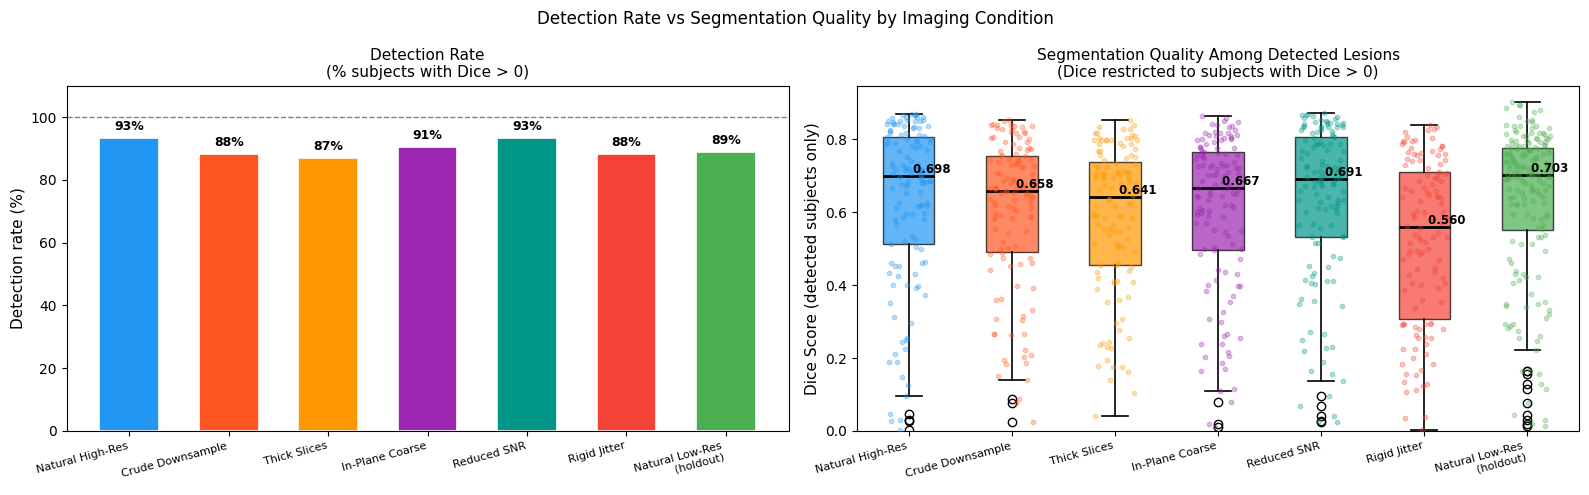


Figure 8 — Detection rate and Dice-among-detected summary:
  delta_det_vs_all: how much detection failures drag down overall mean Dice


,role,n_total,n_detected,det_rate_pct,median_dice_detected,mean_dice_detected,mean_dice_all,delta_det_vs_all
variant,,,,,,,,
Natural High-Res,Training,138,129,93.5,0.698,0.631,0.589,0.041
Crude Downsample,Training,138,122,88.4,0.658,0.602,0.532,0.070
Thick Slices,Training,138,120,87.0,0.641,0.586,0.510,0.076
In-Plane Coarse,Training,138,125,90.6,0.667,0.602,0.545,0.057
Reduced SNR,Training,138,129,93.5,0.691,0.629,0.588,0.041
Rigid Jitter,Training,138,122,88.4,0.560,0.521,0.460,0.060
Natural Low-Res (holdout),Holdout,198,176,88.9,0.703,0.633,0.562,0.070


In [50]:
dice_col = "hard_dice_at_0.50" if "hard_dice_at_0.50" in all_df.columns else "soft_dice"

# Build per-variant arrays of detected-only Dice
det_rates, dice_detected_arrays, labels_plot, colors_plot = [], [], [], []
for v in VARIANT_ORDER:
    sub  = all_df[all_df["variant"] == v]
    dice = sub[dice_col].dropna()
    if len(dice) == 0:
        continue
    det_rates.append(100 * (dice > 0).mean())
    dice_detected_arrays.append(dice[dice > 0].values)
    labels_plot.append(VARIANT_LABEL_MAP.get(v, v).replace(" (holdout)", "\n(holdout)"))
    colors_plot.append(VARIANT_COLORS.get(v, "#aaa"))

x = np.arange(len(labels_plot))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Detection Rate vs Segmentation Quality by Imaging Condition", fontsize=12)

# ── Left panel: Detection rate bar chart ──────────────────────────────────────
ax = axes[0]
bar_kw = dict(edgecolor="white", linewidth=1.2, width=0.6)
bars = ax.bar(x, det_rates, color=colors_plot, **bar_kw)
ax.set_xticks(x); ax.set_xticklabels(labels_plot, fontsize=8, rotation=15, ha="right")
ax.set_ylabel("Detection rate (%)", fontsize=11)
ax.set_ylim(0, 110)
ax.set_title("Detection Rate\n(% subjects with Dice > 0)", fontsize=11)
ax.axhline(100, color="gray", linestyle="--", lw=1)
for bar, val in zip(bars, det_rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
            f"{val:.0f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

# ── Right panel: Dice-among-detected — box-whisker matching Fig 1 style ───────
ax = axes[1]
bp = ax.boxplot(dice_detected_arrays, patch_artist=True, widths=0.5,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2))
for patch, col in zip(bp["boxes"], colors_plot):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)

rng = np.random.default_rng(42)
for j, (arr, col) in enumerate(zip(dice_detected_arrays, colors_plot)):
    jx = rng.uniform(j + 0.78, j + 1.22, size=len(arr))
    ax.scatter(jx, arr, alpha=0.3, s=10, color=col, zorder=3)

# Median value labels on the black median bars
for j, arr in enumerate(dice_detected_arrays):
    med = float(np.median(arr))
    ax.text(j + 1, med, f" {med:.3f}", va="bottom", ha="left",
            fontsize=8.5, color="black", fontweight="bold", zorder=5)

ax.set_xticks(range(1, len(labels_plot) + 1))
ax.set_xticklabels(labels_plot, fontsize=8, rotation=15, ha="right")
ax.set_ylabel("Dice Score (detected subjects only)", fontsize=11)
ax.set_ylim(bottom=0)
ax.set_title("Segmentation Quality Among Detected Lesions\n(Dice restricted to subjects with Dice > 0)", fontsize=11)

plt.tight_layout()
plt.savefig(SAVE_DIR / "fig8_detection_vs_quality.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Detection vs quality summary table ────────────────────────────────────────
_det_rows = []
for v, det_r, det_arr, lbl in zip(VARIANT_ORDER[:len(det_rates)], det_rates, dice_detected_arrays, labels_plot):
    sub   = all_df[all_df["variant"] == v]
    dice  = sub[dice_col].dropna()
    n_tot = len(dice)
    n_det = int((dice > 0).sum())
    _det_rows.append({
        "variant":              lbl.replace("\n", " "),
        "role":                 "Holdout" if v in HOLDOUT_VARIANTS else "Training",
        "n_total":              n_tot,
        "n_detected":           n_det,
        "det_rate_pct":         round(float(det_r), 1),
        "median_dice_detected": round(float(np.median(det_arr)), 3) if len(det_arr) else float("nan"),
        "mean_dice_detected":   round(float(np.mean(det_arr)),   3) if len(det_arr) else float("nan"),
        "mean_dice_all":        round(float(dice.mean()), 3),
        "delta_det_vs_all":     round(float(np.mean(det_arr) - dice.mean()), 3) if len(det_arr) else float("nan"),
    })

_det_df = pd.DataFrame(_det_rows).set_index("variant")
print("\nFigure 8 — Detection rate and Dice-among-detected summary:")
print("  delta_det_vs_all: how much detection failures drag down overall mean Dice")
display(_det_df)


## Figure 8: Detection Rate vs Segmentation Quality — Interpretation

**What the plot shows:** Two bar charts: left shows the detection rate (% subjects where the model produces any non-zero Dice) per imaging condition; right shows the mean Dice *only among subjects where the lesion was detected*. This decomposition separates the two failure modes.

**Key findings and their meaning for stroke lesion segmentation:**

- **Two orthogonal failure modes:** Overall mean Dice conflates (a) the model completely missing a lesion (detection failure, Dice = 0) and (b) the model finding the lesion but with imprecise boundaries (quality failure, Dice > 0 but low). These require different fixes: detection failures call for recall-boosting training strategies (focal loss, harder negatives, lower detection threshold); quality failures call for boundary refinement and better resolution.
- **delta_det_vs_all:** This column quantifies how much detection failures drag down the reported mean Dice. A large delta (e.g. 0.10) means that if the model just detected all lesions, mean Dice would rise by 10 points — detection is the dominant bottleneck. A small delta means the model reliably finds lesions but struggles with boundary precision.
- **Detection rate under degradation:** If detection rate drops substantially (e.g. from 95% on HiRes to 78% on ThickSlices), it means degradation causes complete lesion misses, not just boundary errors. This is the most clinically severe failure — a completely missed lesion = no treatment planning guidance at all.
- **Quality (Dice-among-detected) under degradation:** If Dice-among-detected stays stable across variants while overall mean Dice drops, the degradation is causing more misses but not affecting the boundary quality of lesions the model does find. The model architecture may be robust to image quality in its boundary-drawing but fragile at the detection stage.
- **Natural Low-Res holdout comparison:** If the Natural Low-Res holdout shows a different detection/quality trade-off pattern from the synthetic variants (e.g., lower detection rate but higher Dice-among-detected), this reveals that the synthetic augmentation teaches the model to try harder on blurry images (reducing missed detections) but real low-res images have quality characteristics that don't match the synthetic distribution.
- **Actionable threshold:** Variants with det_rate < 90% should be flagged as needing targeted training intervention. Variants with high det_rate but mean_dice_detected < 0.50 are candidates for boundary-sharpening post-processing or test-time augmentation.


**§ 14 — Non-linear sensitivity analysis (cubic B-spline OLS).** Fits an ordinary-least-squares model with four-degree-of-freedom natural cubic B-spline basis expansions for each quality metric, with cluster-robust standard errors grouped by subject. This non-parametric alternative relaxes the linearity assumption of the primary LME and serves as a sensitivity check: close agreement between the spline and linear holdout metrics supports the adequacy of the linear specification; substantial divergence suggests non-linear quality–accuracy relationships that may warrant further investigation.

In [51]:
# Optional non-linear sensitivity model (GAM-like with cubic B-splines + clustered SEs)
if not active_predictors:
    print("No varying quality predictors available; skipping spline model.")
else:
    spline_terms = [f"bs({col}, df=4, degree=3, include_intercept=False)" for col in active_predictors]
    spline_formula = "1 + " + " + ".join(spline_terms)

    X_train = dmatrix(spline_formula, train_df, return_type="dataframe")
    if train_df["misalign"].nunique() > 1:
        X_train["misalign"] = train_df["misalign"].values

    spline_result = sm.OLS(train_df["logit_dice"], X_train).fit(
        cov_type="cluster",
        cov_kwds={"groups": train_df[GROUP_COL]},
    )

    print(spline_result.summary().tables[0])

    # Holdout prediction for comparison.
    # Clip to training bounds to avoid spline basis extrapolation errors.
    holdout_for_spline = holdout_df.copy()
    for col in active_predictors:
        lo = float(train_df[col].min())
        hi = float(train_df[col].max())
        holdout_for_spline[col] = holdout_for_spline[col].clip(lo, hi)

    X_holdout = dmatrix(X_train.design_info, holdout_for_spline, return_type="dataframe")
    for col in X_train.columns:
        if col not in X_holdout.columns:
            X_holdout[col] = 0.0
    X_holdout = X_holdout[X_train.columns]

    holdout_df["pred_logit_spline"] = spline_result.predict(X_holdout)
    holdout_df["pred_soft_dice_spline"] = expit(holdout_df["pred_logit_spline"])

    obs = holdout_df[OUTCOME].to_numpy(dtype=float)
    pred_spline = holdout_df["pred_soft_dice_spline"].to_numpy(dtype=float)
    res_spline = obs - pred_spline

    spline_metrics = pd.Series(
        {
            "mae_spline": float(np.mean(np.abs(res_spline))),
            "rmse_spline": float(np.sqrt(np.mean(res_spline ** 2))),
            "bias_spline": float(np.mean(res_spline)),
            "pearson_r_spline": float(np.corrcoef(obs, pred_spline)[0, 1]),
        }
    )
    print(spline_metrics.to_string())


                            OLS Regression Results                            
Dep. Variable:             logit_dice   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     5.701
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           2.81e-08
Time:                        12:35:10   Log-Likelihood:                -2150.8
No. Observations:                 828   AIC:                             4330.
Df Residuals:                     814   BIC:                             4396.
Df Model:                          13                                         
Covariance Type:              cluster                                         
mae_spline          0.384342
rmse_spline         0.430248
bias_spline         0.309061
pearson_r_spline    0.062286


## Interpretation Checklist

- Check whether quality predictors actually vary by degradation (see the within-key spread table).
- If predictors do not vary across cohorts, the model can only learn subject-level associations, not degradation penalties.
- Use the holdout calibration bias (`observed - predicted`) to quantify any additional natural low-res penalty.
- If needed, recompute quality metrics directly on degraded images before final manuscript-level inference.


**§ 21 — Fixed-effect collinearity diagnosis (Variance Inflation Factor).** Uses the exact fixed-effect design matrix from the fitted mixed-effects model (`mixed_result.model.exog`) to quantify how much collinearity is inflating the uncertainty of each coefficient. For predictor *j*, VIF\(_j\) = 1 / (1 − R²\(_j\)), where R²\(_j\) is obtained by regressing that predictor on all of the other fixed effects. A VIF near 1 indicates negligible collinearity; values above ~5 suggest meaningful inflation, and values above ~10 suggest severe instability. The square-root of VIF is especially useful here because it directly reports the multiplicative inflation in the coefficient standard error.

Standalone VIF rebuild loading image-level quality metrics from: image_quality_metrics_all_variants_20260414_105233.csv
Standalone VIF rebuild QM merge NaNs: {'mf_fwhm_mm': 888, 'mf_hi_freq_energy': 888, 'mf_lap_var': 888}
Standalone VIF rebuild formula: logit_dice ~ z_mf_fwhm_mm + z_mf_hi_freq_energy + z_mf_lap_var + z_log_lesion_mm3
Standalone VIF rebuild grouping column: mf_key
Standalone VIF rebuild rows: 138
Variance Inflation Factor (VIF) diagnostics from the fitted mixed-model fixed-effect matrix:
  VIF quantifies how much predictor collinearity inflates coefficient variance.
  sqrt(VIF) is the corresponding standard-error inflation factor.


/home/rbielski/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


,label,vif,sqrt_vif,tolerance
term,,,,
z_mf_hi_freq_energy,High-Freq Energy (higher z = more aliasing),92.41,9.61,0.011
z_mf_lap_var,Laplacian Variance (higher z = sharper edges),73.84,8.59,0.014
z_mf_fwhm_mm,FWHM blur (higher z = more blur),7.00,2.65,0.143
z_log_lesion_mm3,Lesion Volume log(mm^3) (higher z = larger les...,1.32,1.15,0.755


HFE vs Laplacian variance correlation in the fixed-effect matrix: r = 0.992
Top pairwise correlations among fixed effects:


,pair,r,abs_r
3,High-Freq Energy (higher z = more aliasing) v...,0.992,0.992
0,FWHM blur (higher z = more blur) vs High-Fre...,-0.917,0.917
1,FWHM blur (higher z = more blur) vs Laplacia...,-0.895,0.895
4,High-Freq Energy (higher z = more aliasing) v...,0.490,0.490
5,Laplacian Variance (higher z = sharper edges) ...,0.486,0.486


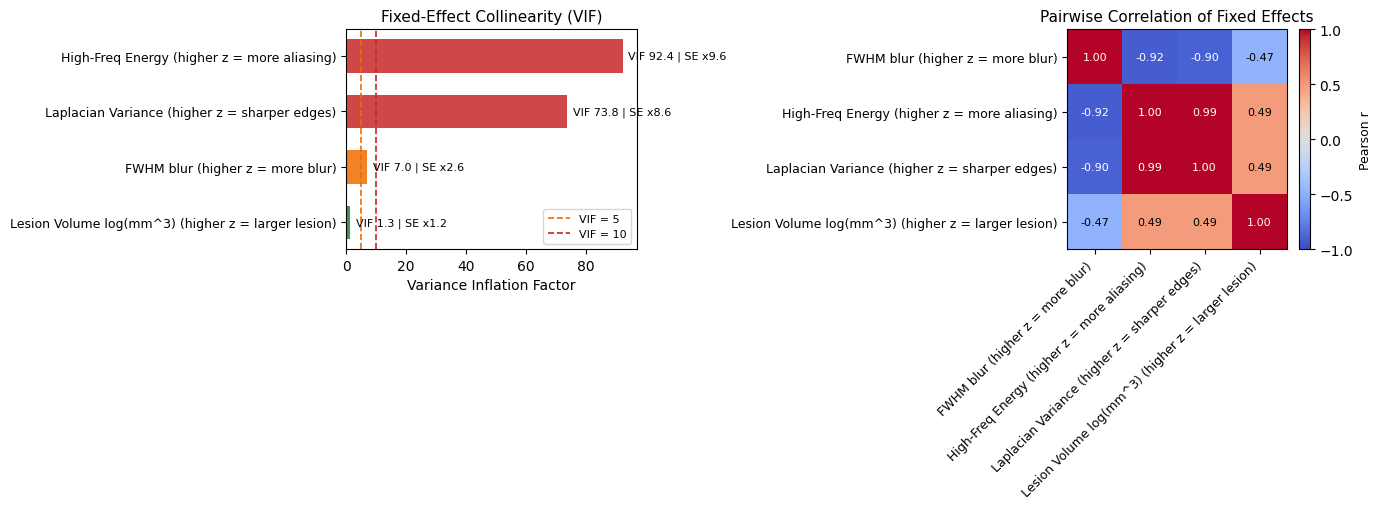

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display
from statsmodels.stats.outliers_influence import variance_inflation_factor

if "TERM_LABELS" not in globals():
    TERM_LABELS = {
        "z_mf_fwhm_mm":       "FWHM blur\n(higher z = more blur)",
        "z_mf_hi_freq_energy": "High-Freq Energy\n(higher z = more aliasing)",
        "z_mf_lap_var":       "Laplacian Variance\n(higher z = sharper edges)",
        "misalign":           "Misalignment flag\n(1 = RigidJitter variant)",
        "z_log_lesion_mm3":   "Lesion Volume log(mm^3)\n(higher z = larger lesion)",
    }

if "SAVE_DIR" not in globals():
    SAVE_DIR = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval")

if "mixed_result" not in globals():
    RUN_DIR = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval")
    assert RUN_DIR.exists(), f"Run directory not found: {RUN_DIR}"

    def latest_csv(pattern):
        matches = sorted(RUN_DIR.glob(pattern))
        return matches[-1].name if matches else None

    variant_globs = [
        {"variant": "hires",              "cohort": "hires", "role": "natural",     "glob": "test_hires_metrics_with_manifest_*.csv"},
        {"variant": "lower_resolution",   "cohort": "lores", "role": "holdout",     "glob": "test_lores_metrics_with_manifest_20251111_143340.csv"},
        {"variant": "crude_downsample",   "cohort": "hires", "role": "degraded",    "glob": "test_crude_metrics_with_manifest_*.csv"},
        {"variant": "thick_slice",        "cohort": "hires", "role": "degraded",    "glob": "test_lores_metrics_with_manifest_20251111_161029.csv"},
        {"variant": "inplane_coarsening", "cohort": "hires", "role": "degraded",    "glob": "test_InPlane_metrics_with_manifest_*.csv"},
        {"variant": "reduced_snr",        "cohort": "hires", "role": "degraded",    "glob": "test_reducedsnr_metrics_with_manifest_*.csv"},
        {"variant": "rigid_jitter",       "cohort": "hires", "role": "degraded",    "glob": "test_slicejitter_metrics_with_manifest_*.csv"},
        {"variant": "synthsr_lores",      "cohort": "lores", "role": "sr_enhanced", "glob": "test_synthsr_lores_metrics_with_manifest_*.csv"},
    ]

    file_specs = []
    for entry in variant_globs:
        fname = latest_csv(entry["glob"])
        if fname is None:
            print(f"[warn] no CSV found for variant '{entry['variant']}' (glob: {entry['glob']}); skipping.")
            continue
        file_specs.append({
            "variant": entry["variant"],
            "cohort": entry["cohort"],
            "role": entry["role"],
            "filename": fname,
        })

    if not file_specs:
        raise RuntimeError("No CSV files found for standalone VIF rebuild.")

    required_manifest_cols = ["key", "soft_dice", "img_path", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]
    dfs = {}
    for spec in file_specs:
        path = RUN_DIR / spec["filename"]
        df = pd.read_csv(path)
        missing_cols = [c for c in required_manifest_cols if c not in df.columns]
        if missing_cols:
            raise ValueError(
                f"{path.name} is missing required manifest columns: {missing_cols}. "
                "Use the *_metrics_with_manifest_*.csv file for this analysis."
            )
        if "dataset_tag" not in df.columns:
            df["dataset_tag"] = spec["cohort"]
        df["cohort"] = spec["cohort"]
        df["variant"] = spec["variant"]
        df["role"] = spec["role"]
        df["source_file"] = path.name
        dfs[spec["variant"]] = df

    all_df = pd.concat(dfs.values(), ignore_index=True)
    all_df["key"] = all_df["key"].astype(str)

    qm_dir = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics")
    qm_csvs = sorted(qm_dir.glob("image_quality_metrics_all_variants_*.csv"))
    if not qm_csvs:
        raise FileNotFoundError(
            f"No image_quality_metrics_all_variants_*.csv found in {qm_dir}. "
            "Run ARC_ATLAS_Image_Quality_Metrics.ipynb first."
        )
    qm_path = qm_csvs[-1]
    print(f"Standalone VIF rebuild loading image-level quality metrics from: {qm_path.name}")
    qm = pd.read_csv(qm_path)
    qm_variant_map = {
        "test_hires": "hires",
        "test_lores": "lower_resolution",
        "Crude": "crude_downsample",
        "ThickSlices": "thick_slice",
        "InPlaneCoarse": "inplane_coarsening",
        "ReducedSNR": "reduced_snr",
        "RigidJitter": "rigid_jitter",
        "synthsr_lores": "synthsr_lores",
    }
    qm["variant"] = qm["variant"].map(qm_variant_map).fillna(qm["variant"])
    qm["key"] = qm["key"].astype(str)
    qm = qm.rename(columns={
        "fwhm_mm": "mf_fwhm_mm",
        "hi_freq_energy": "mf_hi_freq_energy",
        "lap_var": "mf_lap_var",
    })[["key", "variant", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]]

    for c in ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]:
        if c in all_df.columns:
            all_df = all_df.drop(columns=[c])
    all_df = all_df.merge(qm, on=["key", "variant"], how="left")
    print("Standalone VIF rebuild QM merge NaNs:", all_df[["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]].isna().sum().to_dict())

    manifest = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/50_25_25/meta/_resolution_manifest_v2.csv")
    if manifest.exists():
        mf = pd.read_csv(manifest)[["key", "mask_ml_clean"]]
        mf["key"] = mf["key"].astype(str)
        mf["lesion_mm3"] = mf["mask_ml_clean"] * 1000
        mf = mf[["key", "lesion_mm3"]]
        if "lesion_mm3" in all_df.columns:
            all_df = all_df.drop(columns=["lesion_mm3"])
        all_df = all_df.merge(mf, on="key", how="left")
    else:
        all_df["lesion_mm3"] = np.nan
        print(f"WARNING: Resolution manifest not found at {manifest}")

    degraded_variants = [spec["variant"] for spec in file_specs if spec["role"] in ("natural", "degraded")]
    outcome = "soft_dice"
    group_col = "mf_key" if ("mf_key" in all_df.columns and all_df["mf_key"].notna().all()) else "key"
    quality_cols = ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]
    needed = [outcome, "cohort", "variant", "role", "dataset_tag", "key", group_col, "img_path", "lesion_mm3"] + quality_cols
    if "mf_bin" in all_df.columns:
        needed.append("mf_bin")
    work_df = all_df[[c for c in needed if c in all_df.columns]].copy()
    for col in [outcome] + quality_cols:
        work_df[col] = pd.to_numeric(work_df[col], errors="coerce")
    work_df[group_col] = work_df[group_col].astype(str)
    work_df["key"] = work_df["key"].astype(str)
    work_df["log_lesion_mm3"] = np.log1p(work_df["lesion_mm3"].clip(lower=0)) if "lesion_mm3" in work_df.columns else np.nan

    def derive_misalign_flag(df: pd.DataFrame) -> pd.Series:
        if "mf_bin" in df.columns:
            as_num = pd.to_numeric(df["mf_bin"], errors="coerce")
            uniq = set(as_num.dropna().unique().tolist())
            if uniq and uniq.issubset({0.0, 1.0}):
                return as_num.fillna(0).astype(int)
            text_hint = df["mf_bin"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
            if bool(text_hint.any()):
                return text_hint.astype(int)
        variant_hint = df["variant"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
        img_hint = df["img_path"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True) if "img_path" in df.columns else pd.Series(False, index=df.index)
        return (variant_hint | img_hint).astype(int)

    work_df["misalign"] = derive_misalign_flag(work_df)
    train_df = work_df[work_df["variant"].isin(degraded_variants)].copy()
    train_df = train_df.dropna(subset=[outcome, group_col] + quality_cols).copy()

    active_predictors = []
    for col in quality_cols:
        mu = float(train_df[col].mean())
        sd = float(train_df[col].std(ddof=0))
        if not np.isfinite(sd) or sd < 1e-12:
            sd = 1.0
        zcol = f"z_{col}"
        train_df[zcol] = (train_df[col] - mu) / sd
        if float(train_df[zcol].std(ddof=0)) > 1e-12:
            active_predictors.append(zcol)

    if train_df["log_lesion_mm3"].notna().sum() > 0:
        les_mu = float(train_df["log_lesion_mm3"].mean())
        les_sd = float(train_df["log_lesion_mm3"].std(ddof=0)) or 1.0
        train_df["z_log_lesion_mm3"] = (train_df["log_lesion_mm3"] - les_mu) / les_sd
        has_lesion_size = train_df["z_log_lesion_mm3"].notna().sum() > 0
    else:
        has_lesion_size = False

    active_predictors_cat = ["C(variant)"] if (not active_predictors and train_df["variant"].nunique() > 1) else []
    eps = 1e-6
    clipped = np.clip(train_df[outcome].astype(float).values, eps, 1 - eps)
    train_df["logit_dice"] = np.log(clipped / (1 - clipped))

    fixed_terms = list(active_predictors) if active_predictors else list(active_predictors_cat)
    if train_df["misalign"].nunique() > 1:
        fixed_terms.append("misalign")
    if has_lesion_size and "z_log_lesion_mm3" not in fixed_terms:
        fixed_terms.append("z_log_lesion_mm3")
    rhs = " + ".join(fixed_terms) if fixed_terms else "1"
    mixed_formula = f"logit_dice ~ {rhs}"
    print("Standalone VIF rebuild formula:", mixed_formula)
    print("Standalone VIF rebuild grouping column:", group_col)
    mixed_model = smf.mixedlm(
        formula=mixed_formula,
        data=train_df,
        groups=train_df[group_col],
        re_formula="1",
    )
    mixed_result = mixed_model.fit(reml=False, method="lbfgs", maxiter=1000)
    print(f"Standalone VIF rebuild rows: {len(train_df)}")

term_label_map = TERM_LABELS.copy()

vif_exog = pd.DataFrame(
    mixed_result.model.exog,
    columns=mixed_result.model.exog_names,
)
vif_terms = [c for c in vif_exog.columns if c != "Intercept"]

if len(vif_terms) < 2:
    print("VIF is not informative with fewer than two fixed-effect predictors.")
else:
    vif_rows = []
    for term in vif_terms:
        col_idx = vif_exog.columns.get_loc(term)
        vif_val = float(variance_inflation_factor(vif_exog.values, col_idx))
        vif_rows.append(
            {
                "term": term,
                "label": term_label_map.get(term, term).replace("\n", " "),
                "vif": vif_val,
                "sqrt_vif": float(np.sqrt(vif_val)) if np.isfinite(vif_val) and vif_val >= 0 else np.nan,
                "tolerance": float(1.0 / vif_val) if np.isfinite(vif_val) and vif_val > 0 else np.nan,
            }
        )

    vif_table = pd.DataFrame(vif_rows).sort_values("vif", ascending=False).set_index("term")
    print("Variance Inflation Factor (VIF) diagnostics from the fitted mixed-model fixed-effect matrix:")
    print("  VIF quantifies how much predictor collinearity inflates coefficient variance.")
    print("  sqrt(VIF) is the corresponding standard-error inflation factor.")
    vif_display = vif_table.copy()
    vif_display["vif"] = vif_display["vif"].round(2)
    vif_display["sqrt_vif"] = vif_display["sqrt_vif"].round(2)
    vif_display["tolerance"] = vif_display["tolerance"].round(3)
    display(vif_display)

    predictor_corr = vif_exog[vif_terms].corr()

    if {"z_mf_hi_freq_energy", "z_mf_lap_var"}.issubset(predictor_corr.columns):
        hfe_lap_r = float(predictor_corr.loc["z_mf_hi_freq_energy", "z_mf_lap_var"])
        print(f"HFE vs Laplacian variance correlation in the fixed-effect matrix: r = {hfe_lap_r:.3f}")

    abs_pairs = []
    cols = list(predictor_corr.columns)
    for i, left in enumerate(cols):
        for right in cols[i + 1:]:
            r_val = float(predictor_corr.loc[left, right])
            left_label = term_label_map.get(left, left).replace("\n", " ")
            right_label = term_label_map.get(right, right).replace("\n", " ")
            abs_pairs.append(
                {
                    "pair": f"{left_label}  vs  {right_label}",
                    "r": r_val,
                    "abs_r": abs(r_val),
                }
            )
    if abs_pairs:
        top_corr = pd.DataFrame(abs_pairs).sort_values("abs_r", ascending=False)
        print("Top pairwise correlations among fixed effects:")
        top_corr_display = top_corr[["pair", "r", "abs_r"]].head(5).copy()
        top_corr_display["r"] = top_corr_display["r"].round(3)
        top_corr_display["abs_r"] = top_corr_display["abs_r"].round(3)
        display(top_corr_display)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4.5, 0.8 * len(vif_table) + 2.0)))

    ax = axes[0]
    y = np.arange(len(vif_table))
    vif_colors = [
        "#c62828" if v >= 10 else "#ef6c00" if v >= 5 else "#2e7d32"
        for v in vif_table["vif"]
    ]
    bars = ax.barh(y, vif_table["vif"].values, color=vif_colors, alpha=0.85, height=0.6)
    ax.axvline(5, color="#ef6c00", linestyle="--", linewidth=1.2, label="VIF = 5")
    ax.axvline(10, color="#c62828", linestyle="--", linewidth=1.2, label="VIF = 10")
    ax.set_yticks(y)
    ax.set_yticklabels(vif_table["label"], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Variance Inflation Factor", fontsize=10)
    ax.set_title("Fixed-Effect Collinearity (VIF)", fontsize=11)
    ax.legend(loc="lower right", fontsize=8, frameon=True)
    x_pad = max(float(vif_table["vif"].max()) * 0.02, 0.15)
    for i, (_, row) in enumerate(vif_table.iterrows()):
        bar = bars[i]
        ax.text(
            float(row["vif"]) + x_pad,
            bar.get_y() + bar.get_height() / 2,
            f"VIF {row['vif']:.1f} | SE x{row['sqrt_vif']:.1f}",
            va="center",
            fontsize=8,
        )

    ax = axes[1]
    corr_labels = [term_label_map.get(t, t).replace("\n", " ") for t in predictor_corr.columns]
    im = ax.imshow(predictor_corr.values, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(np.arange(len(corr_labels)))
    ax.set_yticks(np.arange(len(corr_labels)))
    ax.set_xticklabels(corr_labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(corr_labels, fontsize=9)
    ax.set_title("Pairwise Correlation of Fixed Effects", fontsize=11)
    for i in range(predictor_corr.shape[0]):
        for j in range(predictor_corr.shape[1]):
            r_val = float(predictor_corr.iloc[i, j])
            ax.text(
                j,
                i,
                f"{r_val:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if abs(r_val) >= 0.65 else "black",
            )
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pearson r", fontsize=9)

    plt.tight_layout()
    if "SAVE_DIR" in globals():
        plt.savefig(SAVE_DIR / "fig9_vif_collinearity.png", dpi=150, bbox_inches="tight")
    plt.show()

## Figure 9: VIF Collinearity Diagnostics — Interpretation

**What the plot shows:** The left panel reports the Variance Inflation Factor for each fixed effect in the mixed model. VIF = 1 means the predictor is orthogonal to the others; values above ~5 usually indicate meaningful multicollinearity, and values above ~10 indicate severe inflation of coefficient uncertainty. The annotation `SE x...` is \(\sqrt{\mathrm{VIF}}\), which is the multiplicative inflation in that coefficient’s standard error. The right panel shows the pairwise Pearson correlation matrix for the same fixed effects.

**How to read the HFE / LapVar issue:** If high-frequency energy and Laplacian variance have very large VIF and a pairwise correlation close to ±1, the model is being asked to separate two almost redundant sharpness signals. In that setting, each coefficient becomes a *conditional* effect after holding the other nearly identical metric fixed, which can make one coefficient shrink, widen substantially, or even flip sign despite both metrics having similar marginal relationships with Dice.

**Practical takeaway for this notebook:** Large VIF values do not invalidate the mixed model’s overall predictive signal, but they do weaken the interpretability of the individual HFE and LapVar coefficients as independent mechanisms. If manuscript-level inference requires stable sign interpretation, the next step would be to compare this full model against a reduced one-metric-at-a-time model, a penalised model, or a single shared sharpness summary (for example one representative metric or a principal component).